<span style="font-family: Arial; font-weight:bold;font-size:1.5em;color:#0e92ea"> Learner
<font color=darkblue>: **Caio Maluf Schiefer**

<font color=darkblue> **QM 640: Capstone Analytics Project**
<span style="font-family: Arial; font-weight:bold;font-size:1.5em;color:#0e92ea">


    
<span style="font-family: Arial; font-weight:bold;font-size:1.5em;color:#0e92ea"> Submission Date:
<font color=darkblue>: **27 Aug 2026**

    
<span style="font-family: Arial; font-weight:bold;font-size:1.5em;color:#0e92ea"> GitHub Address of this assignment
<font color=darkblue>:
    https://github.com/caioschiefer-degree/Walsh.git

## Learner's Notes and Considerations:

This notebook has been completed using **Google Colab** and **Python 3** as default. This was executed with **CPU** only.

Below I am bringing the questions from the submission instructions for proper tracking and to facilitate the reading, on top of the existing strucutre of this notebook.

I'm also moving the original instructions to an Appendix section at the end of this notebook for clarity and future reference.

#Environment Setup

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
DATA_DIR = "/content/drive/MyDrive/Walsh/QM640 - Analytics Capstone/data/" # separate provided test set stored here

In [3]:
import numpy as np
import pandas as pd
from statsmodels.stats.outliers_influence import variance_inflation_factor
import matplotlib.pyplot as plt
import statsmodels.api as sm
import statsmodels.formula.api as smf
from scipy import stats
from sklearn.model_selection import GroupKFold
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import confusion_matrix, roc_curve, roc_auc_score, ConfusionMatrixDisplay
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.metrics import (
    mean_squared_error, mean_absolute_error, r2_score,
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    confusion_matrix, roc_curve
)
from sklearn.preprocessing import StandardScaler

In [4]:
!pip install pycountry

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.0/8.0 MB 31.7 MB/s eta 0:00:00


#EDA

##Data Merging and Cleansing

###WDI

In [5]:
# 9 predictor codes from the Data Dictionary
predictor_codes = [
    'GOV_WGI_CC_EST','GOV_WGI_PV_EST', 'GOV_WGI_RL_EST',
    'IT.NET.BBND.P2', 'IT.CEL.SETS.P2', 'NY.GDP.PCAP.PP.CD',
    'SE.TER.ENRR', 'IP.JRN.ARTC.SC', 'TX.VAL.TECH.MF.ZS'
]

# Read only the columns you need, in chunks if the file is large
df = pd.read_csv('/content/drive/MyDrive/Walsh/QM640 - Analytics Capstone/data/raw/wdi/WDICSV.csv', usecols=lambda c: c in [
    'Country Name', 'Country Code', 'Indicator Code'
] + [str(y) for y in range(2020, 2026)])  # adjust year range to your study window

filtered = df[df['Indicator Code'].isin(predictor_codes)]
filtered.to_csv(DATA_DIR + 'processed/wdi_predictors_filtered.csv', index=False)

In [6]:
df = pd.read_csv(DATA_DIR + 'processed/wdi_predictors_filtered.csv')  # adjust path if needed in Colab

# Shape and columns
print("Shape:", df.shape)
print("Columns:", list(df.columns))

# First few rows
df.head(10)


Shape: (2394, 9)
Columns: ['Country Name', 'Country Code', 'Indicator Code', '2020', '2021', '2022', '2023', '2024', '2025']


,Country Name,Country Code,Indicator Code,2020,2021,2022,2023,2024,2025
0,Africa Eastern and Southern,AFE,GOV_WGI_CC_EST,NaN,NaN,NaN,NaN,NaN,NaN
1,Africa Eastern and Southern,AFE,IT.NET.BBND.P2,0.510000,0.620000,0.670000,0.780000,1.030000,1.41
2,Africa Eastern and Southern,AFE,NY.GDP.PCAP.PP.CD,3708.094649,4028.376504,4369.191056,4501.601101,4635.788224,NaN
3,Africa Eastern and Southern,AFE,TX.VAL.TECH.MF.ZS,6.066723,5.176600,6.316269,5.704851,5.800044,NaN
4,Africa Eastern and Southern,AFE,IT.CEL.SETS.P2,69.900000,74.700000,77.700000,82.300000,87.300000,93.10
5,Africa Eastern and Southern,AFE,GOV_WGI_PV_EST,NaN,NaN,NaN,NaN,NaN,NaN
6,Africa Eastern and Southern,AFE,GOV_WGI_RL_EST,NaN,NaN,NaN,NaN,NaN,NaN
7,Africa Eastern and Southern,AFE,SE.TER.ENRR,8.711870,8.661860,NaN,NaN,NaN,NaN
8,Africa Eastern and Southern,AFE,IP.JRN.ARTC.SC,26268.790000,29049.200000,31334.300000,30626.160000,NaN,NaN
9,Africa Western and Central,AFW,GOV_WGI_CC_EST,NaN,NaN,NaN,NaN,NaN,NaN


In [7]:
YEAR_COLS = [c for c in df.columns if c.isdigit()]
print("Year columns detected:", YEAR_COLS)

# ------------------------------------------------------------
# 2a. Missingness by indicator (all countries, all years pooled)
# ------------------------------------------------------------
print("\n--- Missing % by Indicator Code (all countries/years pooled) ---")
miss_by_indicator = (
    df.groupby('Indicator Code')[YEAR_COLS]
    .apply(lambda g: g.isna().mean().mean() * 100)
    .round(1)
    .sort_values(ascending=False)
)
print(miss_by_indicator)



Year columns detected: ['2020', '2021', '2022', '2023', '2024', '2025']

--- Missing % by Indicator Code (all countries/years pooled) ---
Indicator Code
SE.TER.ENRR          49.2
IP.JRN.ARTC.SC       38.8
TX.VAL.TECH.MF.ZS    38.0
GOV_WGI_CC_EST       35.6
GOV_WGI_PV_EST       35.5
GOV_WGI_RL_EST       35.5
IT.NET.BBND.P2       26.9
IT.CEL.SETS.P2       25.9
NY.GDP.PCAP.PP.CD    23.7
dtype: float64


In [8]:
# ------------------------------------------------------------
# 2b. Missingness by year (all countries, all indicators pooled)
# ------------------------------------------------------------
print("\n--- Missing % by Year (all countries/indicators pooled) ---")
miss_by_year = df[YEAR_COLS].isna().mean().mul(100).round(1)
print(miss_by_year)




--- Missing % by Year (all countries/indicators pooled) ---
2020    16.8
2021    16.8
2022    17.3
2023    21.5
2024    36.9
2025    97.0
dtype: float64


In [9]:
# ------------------------------------------------------------
# 2c. Missingness by indicator x year (the full grid)
# ------------------------------------------------------------
print("\n--- Missing % by Indicator x Year ---")
miss_grid = (
    df.set_index(['Indicator Code', 'Country Code'])[YEAR_COLS]
    .isna()
    .groupby(level='Indicator Code')
    .mean()
    .mul(100)
    .round(1)
)
print(miss_grid)




--- Missing % by Indicator x Year ---
                   2020  2021  2022  2023   2024   2025
Indicator Code                                         
GOV_WGI_CC_EST     23.3  22.6  22.6  22.6   22.6  100.0
GOV_WGI_PV_EST     22.6  22.6  22.6  22.6   22.6  100.0
GOV_WGI_RL_EST     22.6  22.6  22.6  22.6   22.6  100.0
IP.JRN.ARTC.SC      8.3   8.3   8.3   8.3  100.0  100.0
IT.CEL.SETS.P2      4.5   4.1   4.5  23.3   31.2   88.0
IT.NET.BBND.P2      6.8   5.6   5.6  24.4   31.2   88.0
NY.GDP.PCAP.PP.CD   7.5   7.5   7.5   8.3   11.7  100.0
SE.TER.ENRR        33.5  36.5  39.1  38.3   51.1   96.6
TX.VAL.TECH.MF.ZS  21.8  21.1  22.6  23.3   39.5  100.0


In [10]:
# ------------------------------------------------------------
# 2d. Missingness by country (across all 9 indicators, at 2023
#     specifically, since that's the anchor year in the synopsis)
# ------------------------------------------------------------
print("\n--- Missing count by Country at 2023 (out of 9 predictors) ---")
pivot_2023 = df.pivot(index='Country Code', columns='Indicator Code', values='2023')
miss_by_country_2023 = pivot_2023.isna().sum(axis=1).sort_values(ascending=False)
print(miss_by_country_2023.head(30))  # worst 30 first
print(f"... ({len(miss_by_country_2023)} countries total)")




--- Missing count by Country at 2023 (out of 9 predictors) ---
Country Code
CHI    9
MAF    9
MNP    9
FCS    9
GIB    9
INX    9
IMN    9
FRO    8
PRE    7
TCA    7
SXM    7
CSS    6
CUW    6
HPC    6
NCL    6
VGB    6
ASM    6
VIR    6
GUM    6
OSS    5
MIC    5
TMN    5
PRK    5
PST    5
PSS    5
CEB    5
ARB    5
EMU    5
OED    5
MNA    5
dtype: int64
... (266 countries total)


In [11]:
# ------------------------------------------------------------
# 2e. Which 'Country Code' values are NOT real countries?
#     Using pycountry's ISO3 list as the reference.
#     (Just flagging here -- not removing anything yet.)
# ------------------------------------------------------------
import pycountry
valid_iso3 = {c.alpha_3 for c in pycountry.countries}

df['is_real_country'] = df['Country Code'].isin(valid_iso3)

not_real = (
    df.loc[~df['is_real_country'], ['Country Code', 'Country Name']]
    .drop_duplicates()
    .sort_values('Country Code')
)
print(f"\n--- Country Code values NOT matching a real ISO3 country: {len(not_real)} ---")
print(not_real.to_string(index=False))

print(f"\nTotal distinct Country Code values in file: {df['Country Code'].nunique()}")
print(f"Of which real ISO3 countries: {df.loc[df['is_real_country'], 'Country Code'].nunique()}")
print(f"Of which NOT real countries (aggregates/regions/etc.): {not_real['Country Code'].nunique()}")


--- Country Code values NOT matching a real ISO3 country: 51 ---
Country Code                                                              Country Name
         AFE                                               Africa Eastern and Southern
         AFW                                                Africa Western and Central
         ARB                                                                Arab World
         CEB                                            Central Europe and the Baltics
         CHI                                                           Channel Islands
         CSS                                                    Caribbean small states
         EAP                               East Asia & Pacific (excluding high income)
         EAR                                                Early-demographic dividend
         EAS                                                       East Asia & Pacific
         ECA                             Europe & Central Asia (

In [12]:
n_before = df['Country Code'].nunique()
removed = (
    df.loc[~df['is_real_country'], ['Country Code', 'Country Name']]
    .drop_duplicates()
    .sort_values('Country Code')
)
print(f"Distinct Country Code values before removal: {n_before}")


# ------------------------------------------------------------
# 3b. Actually remove them
# ------------------------------------------------------------
df = df[df['is_real_country']].drop(columns='is_real_country').copy()
n_after = df['Country Code'].nunique()
print(f"\nDistinct Country Code values after removal: {n_after}")

# ------------------------------------------------------------
# 3c. Re-run: Missingness by indicator (all countries/years pooled)
# ------------------------------------------------------------
print("\n--- Missing % by Indicator Code (real countries only) ---")
miss_by_indicator = (
    df.groupby('Indicator Code')[YEAR_COLS]
    .apply(lambda g: g.isna().mean().mean() * 100)
    .round(1)
    .sort_values(ascending=False)
)
print(miss_by_indicator)

# ------------------------------------------------------------
# 3d. Re-run: Missingness by year (all countries/indicators pooled)
# ------------------------------------------------------------
print("\n--- Missing % by Year (real countries only) ---")
miss_by_year = df[YEAR_COLS].isna().mean().mul(100).round(1)
print(miss_by_year)

# ------------------------------------------------------------
# 3e. Re-run: Missingness by indicator x year (the full grid)
# ------------------------------------------------------------
print("\n--- Missing % by Indicator x Year (real countries only) ---")
miss_grid = (
    df.set_index(['Indicator Code', 'Country Code'])[YEAR_COLS]
    .isna()
    .groupby(level='Indicator Code')
    .mean()
    .mul(100)
    .round(1)
)
print(miss_grid)

# ------------------------------------------------------------
# 3f. Re-run: Missing count by country at 2023 (out of 9 predictors)
# ------------------------------------------------------------
print("\n--- Missing count by Country at 2023 (real countries only) ---")
pivot_2023 = df.pivot(index='Country Code', columns='Indicator Code', values='2023')
miss_by_country_2023 = pivot_2023.isna().sum(axis=1).sort_values(ascending=False)
print(miss_by_country_2023.head(30))
print(f"... ({len(miss_by_country_2023)} countries total)")

Distinct Country Code values before removal: 266

Distinct Country Code values after removal: 215

--- Missing % by Indicator Code (real countries only) ---
Indicator Code
SE.TER.ENRR          52.3
TX.VAL.TECH.MF.ZS    39.6
IP.JRN.ARTC.SC       39.2
IT.NET.BBND.P2       27.8
IT.CEL.SETS.P2       26.7
NY.GDP.PCAP.PP.CD    24.3
GOV_WGI_CC_EST       20.7
GOV_WGI_PV_EST       20.5
GOV_WGI_RL_EST       20.5
dtype: float64

--- Missing % by Year (real countries only) ---
2020    11.5
2021    11.5
2022    11.5
2023    15.5
2024    31.6
2025    99.5
dtype: float64

--- Missing % by Indicator x Year (real countries only) ---
                   2020  2021  2022  2023   2024   2025
Indicator Code                                         
GOV_WGI_CC_EST      5.6   4.7   4.7   4.7    4.7  100.0
GOV_WGI_PV_EST      4.7   4.7   4.7   4.7    4.7  100.0
GOV_WGI_RL_EST      4.7   4.7   4.7   4.7    4.7  100.0
IP.JRN.ARTC.SC      8.8   8.8   8.8   8.8  100.0  100.0
IT.CEL.SETS.P2      3.7   3.3   3.3  20.

COMMENT ON THE COUNTRIES WITH NO PREDICTORS, ETC

In [13]:
# ------------------------------------------------------------
# 4a. Melt: year columns -> 'year' + 'value'
# ------------------------------------------------------------
long_df = df.melt(
    id_vars=['Country Name', 'Country Code', 'Indicator Code'],
    value_vars=YEAR_COLS,
    var_name='year',
    value_name='value'
)
long_df['year'] = long_df['year'].astype(int)

print(f"\nLong format shape: {long_df.shape}")
print("(expected: n_countries x 9 indicators x 6 years)")
print(long_df.head(10))

# ------------------------------------------------------------
# 4b. Pivot: Indicator Code -> columns
#     Result: one row per Country Code x year, one column per predictor
# ------------------------------------------------------------
wide_df = long_df.pivot_table(
    index=['Country Code', 'year'],   # Country Name deliberately excluded here --
                                        # including it caused a cartesian-product bug
                                        # (every code got cross-joined with every name)
    columns='Indicator Code',
    values='value',
    aggfunc='first',  # each cell should already be unique; 'first' just guards against silent duplication
    dropna=False       # keep country-year rows even if ALL 9 indicators are NaN for them --
                        # default (dropna=True) silently removes these, hiding real coverage gaps
).reset_index()

wide_df.columns.name = None  # cleans up the column index label left by pivot_table

# Re-attach Country Name via a clean one-row-per-code lookup (avoids the
# cartesian-product problem from putting Country Name in the pivot index)
name_lookup = df[['Country Code', 'Country Name']].drop_duplicates(subset='Country Code')
wide_df = wide_df.merge(name_lookup, on='Country Code', how='left')
wide_df = wide_df[['Country Code', 'Country Name', 'year'] +
                   [c for c in wide_df.columns if c not in ('Country Code', 'Country Name', 'year')]]

expected_rows = df['Country Code'].nunique() * len(YEAR_COLS)
print(f"\nWide (panel) format shape: {wide_df.shape}")
print(f"Expected rows (n_countries x n_years): {expected_rows}")
if len(wide_df) != expected_rows:
    print(f"MISMATCH of {expected_rows - len(wide_df)} rows -- investigating...")

print(wide_df.head(10))

# ------------------------------------------------------------
# Which country-years are fully missing across all 9 predictors?
# ------------------------------------------------------------
predictor_cols = [c for c in wide_df.columns if c not in ('Country Code', 'Country Name', 'year')]
fully_missing_mask = wide_df[predictor_cols].isna().all(axis=1)
fully_missing = wide_df.loc[fully_missing_mask, ['Country Code', 'Country Name', 'year']]
print(f"\n{len(fully_missing)} country-year rows are missing ALL 9 predictors:")
print(fully_missing.to_string(index=False))

# ------------------------------------------------------------
# Save both versions
# ------------------------------------------------------------
long_df.to_csv(DATA_DIR + 'processed/wdi_predictors_long.csv', index=False)
wide_df.to_csv(DATA_DIR + 'processed/wdi_predictors_panel.csv', index=False)
print("\nSaved: wdi_predictors_long.csv, wdi_predictors_panel.csv")


Long format shape: (11610, 5)
(expected: n_countries x 9 indicators x 6 years)
  Country Name Country Code     Indicator Code  year        value
0  Afghanistan          AFG     GOV_WGI_CC_EST  2020    -1.400890
1  Afghanistan          AFG     IT.NET.BBND.P2  2020     0.068008
2  Afghanistan          AFG  NY.GDP.PCAP.PP.CD  2020  2561.981761
3  Afghanistan          AFG  TX.VAL.TECH.MF.ZS  2020          NaN
4  Afghanistan          AFG     IT.CEL.SETS.P2  2020    58.046114
5  Afghanistan          AFG     GOV_WGI_PV_EST  2020    -2.589690
6  Afghanistan          AFG     GOV_WGI_RL_EST  2020    -1.655664
7  Afghanistan          AFG        SE.TER.ENRR  2020    10.854360
8  Afghanistan          AFG     IP.JRN.ARTC.SC  2020   140.250000
9      Albania          ALB     GOV_WGI_CC_EST  2020    -0.659431

Wide (panel) format shape: (1290, 12)
Expected rows (n_countries x n_years): 1290
  Country Code Country Name  year  GOV_WGI_CC_EST  GOV_WGI_PV_EST  \
0          ABW        Aruba  2020        1

####Outliers and Off Range Values

Saved table_descriptive_stats.csv
                                                             label   count  \
GOV_WGI_CC_EST                               Control of Corruption  1023.0   
GOV_WGI_PV_EST           Political Stability & Absence of Violence  1025.0   
GOV_WGI_RL_EST                                         Rule of Law  1025.0   
IP.JRN.ARTC.SC     Scientific & Technical Journal Articles (count)   784.0   
IT.CEL.SETS.P2             Mobile Cellular Subscriptions (per 100)   946.0   
IT.NET.BBND.P2             Fixed Broadband Subscriptions (per 100)   931.0   
NY.GDP.PCAP.PP.CD                        GDP per capita, PPP (USD)   977.0   
SE.TER.ENRR                           Tertiary Enrolment (% gross)   615.0   
TX.VAL.TECH.MF.ZS    High-Technology Exports (% of manuf. exports)   779.0   

                           mean           std         min          25%  \
GOV_WGI_CC_EST        -0.020150      0.991540   -2.064721    -0.775538   
GOV_WGI_PV_EST        -0.006013      

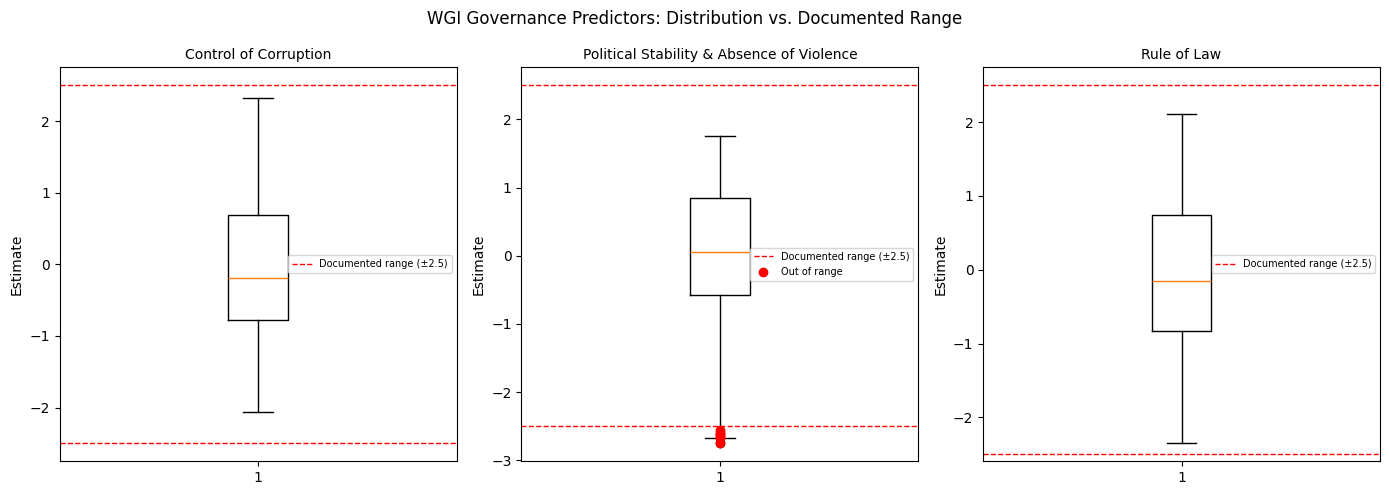


Saved plot_wgi_boxplots.png


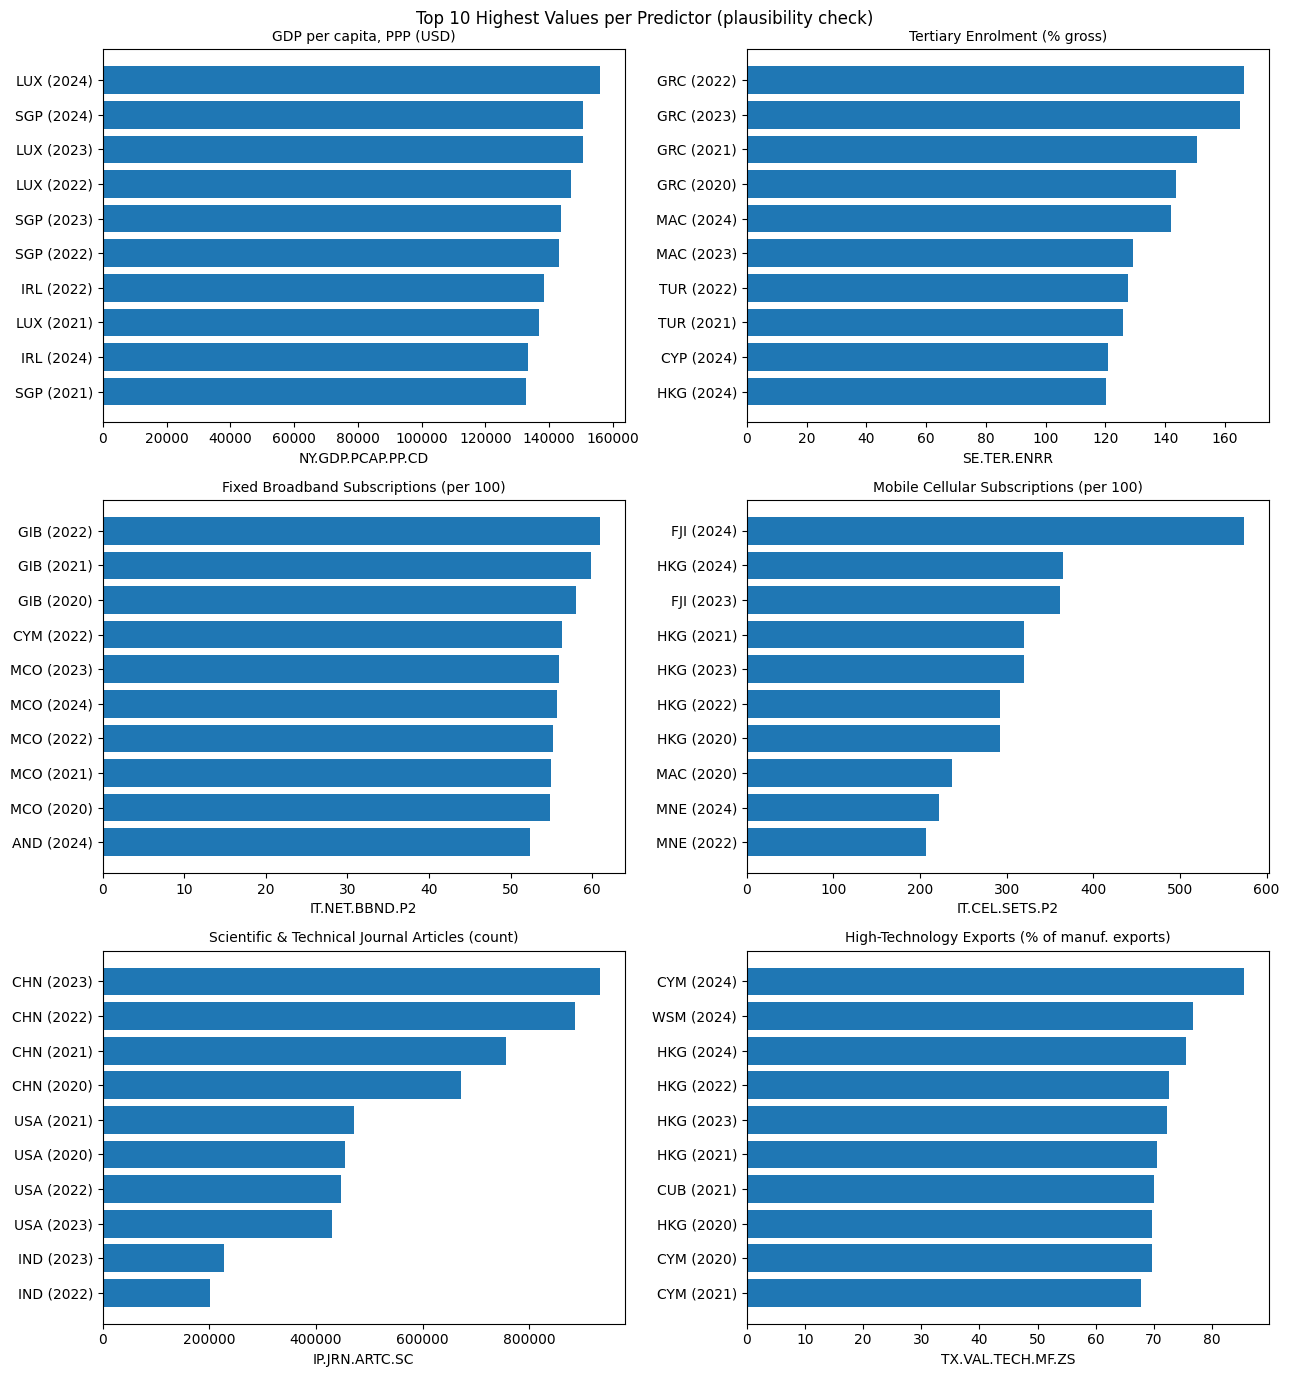

Saved plot_top10_predictors.png
Saved table_top10_<indicator>.csv for each of: ['NY.GDP.PCAP.PP.CD', 'SE.TER.ENRR', 'IT.NET.BBND.P2', 'IT.CEL.SETS.P2', 'IP.JRN.ARTC.SC', 'TX.VAL.TECH.MF.ZS']

Saved table_range_check_summary.csv
        indicator              check  n_flagged_rows
NY.GDP.PCAP.PP.CD         value <= 0               0
      SE.TER.ENRR          value < 0               0
   IT.NET.BBND.P2          value < 0               0
   IT.CEL.SETS.P2          value < 0               0
TX.VAL.TECH.MF.ZS value < 0 or > 100               0
   IP.JRN.ARTC.SC          value < 0               0
   GOV_WGI_CC_EST   outside -2.5/2.5               0
   GOV_WGI_PV_EST   outside -2.5/2.5               8
   GOV_WGI_RL_EST   outside -2.5/2.5               0

=== DONE ===
Files produced:
 - table_descriptive_stats.csv
 - table_wgi_out_of_range.csv
 - table_range_check_summary.csv
 - table_top10_<indicator>.csv (x6)
 - plot_wgi_boxplots.png
 - plot_top10_predictors.png


In [14]:
# ============================================================
# STEP 5b: Range / outlier sanity checks on wdi_predictors_panel.csv
#          -- WITH saved tables (CSV) and plots (PNG) for use in
#             the capstone write-up
# ============================================================

df = pd.read_csv(DATA_DIR + 'processed/wdi_predictors_panel.csv')
predictor_cols = [c for c in df.columns if c not in ('Country Code', 'Country Name', 'year')]

LABELS = {
    'GOV_WGI_CC_EST': 'Control of Corruption',
    'GOV_WGI_PV_EST': 'Political Stability & Absence of Violence',
    'GOV_WGI_RL_EST': 'Rule of Law',
    'IT.NET.BBND.P2': 'Fixed Broadband Subscriptions (per 100)',
    'IT.CEL.SETS.P2': 'Mobile Cellular Subscriptions (per 100)',
    'NY.GDP.PCAP.PP.CD': 'GDP per capita, PPP (USD)',
    'SE.TER.ENRR': 'Tertiary Enrolment (% gross)',
    'IP.JRN.ARTC.SC': 'Scientific & Technical Journal Articles (count)',
    'TX.VAL.TECH.MF.ZS': 'High-Technology Exports (% of manuf. exports)',
}

# ------------------------------------------------------------
# 1. Descriptive stats table -> CSV
# ------------------------------------------------------------
desc = df[predictor_cols].describe().T
desc.insert(0, 'label', [LABELS[c] for c in desc.index])
desc.to_csv(DATA_DIR + 'processed/table_descriptive_stats.csv')
print("Saved table_descriptive_stats.csv")
print(desc)

# ------------------------------------------------------------
# 2. WGI out-of-range table (-2.5 to 2.5) -> CSV
# ------------------------------------------------------------
wgi_cols = ['GOV_WGI_CC_EST', 'GOV_WGI_PV_EST', 'GOV_WGI_RL_EST']
out_of_range_frames = []
for col in wgi_cols:
    bad = df[(df[col] < -2.5) | (df[col] > 2.5)][['Country Code', 'Country Name', 'year', col]].copy()
    bad = bad.rename(columns={col: 'value'})
    bad.insert(0, 'indicator', col)
    out_of_range_frames.append(bad)
wgi_out_of_range = pd.concat(out_of_range_frames, ignore_index=True)
wgi_out_of_range.to_csv(DATA_DIR + 'processed/table_wgi_out_of_range.csv', index=False)
print(f"\nSaved table_wgi_out_of_range.csv ({len(wgi_out_of_range)} rows)")
print(wgi_out_of_range)

# ------------------------------------------------------------
# 3. Plot: WGI boxplots with -2.5/2.5 reference lines and
#    out-of-range points highlighted
# ------------------------------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
for ax, col in zip(axes, wgi_cols):
    ax.boxplot(df[col].dropna(), vert=True)
    ax.axhline(2.5, color='red', linestyle='--', linewidth=1, label='Documented range (±2.5)')
    ax.axhline(-2.5, color='red', linestyle='--', linewidth=1)
    bad_vals = df[(df[col] < -2.5) | (df[col] > 2.5)][col]
    if len(bad_vals):
        ax.scatter([1] * len(bad_vals), bad_vals, color='red', zorder=5, label='Out of range')
    ax.set_title(LABELS[col], fontsize=10)
    ax.set_ylabel('Estimate')
    ax.legend(fontsize=7)
plt.suptitle('WGI Governance Predictors: Distribution vs. Documented Range')
plt.tight_layout()
plt.savefig(DATA_DIR + 'processed/plot_wgi_boxplots.png', dpi=150)
plt.show()
plt.close()
print("\nSaved plot_wgi_boxplots.png")

# ------------------------------------------------------------
# 4. Top-10 tables + bar charts for the WDI predictors most
#    worth eyeballing for plausibility
# ------------------------------------------------------------
top10_targets = [
    'NY.GDP.PCAP.PP.CD', 'SE.TER.ENRR', 'IT.NET.BBND.P2',
    'IT.CEL.SETS.P2', 'IP.JRN.ARTC.SC', 'TX.VAL.TECH.MF.ZS'
]

fig, axes = plt.subplots(3, 2, figsize=(13, 14))
axes = axes.flatten()
for ax, col in zip(axes, top10_targets):
    top10 = df.nlargest(10, col)[['Country Code', 'year', col]].copy()
    #top10.to_csv(f'table_top10_{col.replace(".", "_")}.csv', index=False)
    top10.to_csv(DATA_DIR + 'processed/'+f'table_top10_{col.replace(".", "_")}.csv', index=False)
    labels = top10['Country Code'] + ' (' + top10['year'].astype(str) + ')'
    ax.barh(labels[::-1], top10[col][::-1])
    ax.set_title(LABELS[col], fontsize=10)
    ax.set_xlabel(col)
plt.suptitle('Top 10 Highest Values per Predictor (plausibility check)')
plt.tight_layout()
plt.savefig(DATA_DIR + 'processed/plot_top10_predictors.png', dpi=150)
plt.show()
plt.close()
print("Saved plot_top10_predictors.png")
print("Saved table_top10_<indicator>.csv for each of:", top10_targets)

# ------------------------------------------------------------
# 5. Negative / out-of-bound value checks -> single summary table
# ------------------------------------------------------------
checks = []
checks.append(('NY.GDP.PCAP.PP.CD', 'value <= 0', (df['NY.GDP.PCAP.PP.CD'] <= 0).sum()))
checks.append(('SE.TER.ENRR', 'value < 0', (df['SE.TER.ENRR'] < 0).sum()))
checks.append(('IT.NET.BBND.P2', 'value < 0', (df['IT.NET.BBND.P2'] < 0).sum()))
checks.append(('IT.CEL.SETS.P2', 'value < 0', (df['IT.CEL.SETS.P2'] < 0).sum()))
checks.append(('TX.VAL.TECH.MF.ZS', 'value < 0 or > 100', ((df['TX.VAL.TECH.MF.ZS'] < 0) | (df['TX.VAL.TECH.MF.ZS'] > 100)).sum()))
checks.append(('IP.JRN.ARTC.SC', 'value < 0', (df['IP.JRN.ARTC.SC'] < 0).sum()))
checks.append(('GOV_WGI_CC_EST', 'outside -2.5/2.5', ((df['GOV_WGI_CC_EST'] < -2.5) | (df['GOV_WGI_CC_EST'] > 2.5)).sum()))
checks.append(('GOV_WGI_PV_EST', 'outside -2.5/2.5', ((df['GOV_WGI_PV_EST'] < -2.5) | (df['GOV_WGI_PV_EST'] > 2.5)).sum()))
checks.append(('GOV_WGI_RL_EST', 'outside -2.5/2.5', ((df['GOV_WGI_RL_EST'] < -2.5) | (df['GOV_WGI_RL_EST'] > 2.5)).sum()))

checks_df = pd.DataFrame(checks, columns=['indicator', 'check', 'n_flagged_rows'])
checks_df.to_csv(DATA_DIR + 'processed/table_range_check_summary.csv', index=False)
print("\nSaved table_range_check_summary.csv")
print(checks_df.to_string(index=False))

print("\n=== DONE ===")
print("Files produced:")
print(" - table_descriptive_stats.csv")
print(" - table_wgi_out_of_range.csv")
print(" - table_range_check_summary.csv")
print(" - table_top10_<indicator>.csv (x6)")
print(" - plot_wgi_boxplots.png")
print(" - plot_top10_predictors.png")

###WGI

In [15]:
DATA_DIR

'/content/drive/MyDrive/Walsh/QM640 - Analytics Capstone/data/'

In [16]:
WGI_PATH = DATA_DIR + 'raw/wgi/wgidataset_with_sourcedata-2025.xlsx'  # adjust path if needed

df = pd.read_excel(
    WGI_PATH,
    sheet_name='rl',  # any tab works -- Region/Income are identical across tabs
    usecols=['Economy (code)', 'Economy (name)', 'Region', 'Income classification', 'Year']
)

# Restrict to the study window, since that's what actually matters
# for the imputation peer groups (2020-2024; 2025 predictor data
# doesn't exist, as already established)
df_window = df[df['Year'].between(2020, 2024)].copy()

# ------------------------------------------------------------
# Check 1: Region -- how many distinct values per country?
# ------------------------------------------------------------
region_changes = (
    df_window.groupby('Economy (code)')['Region']
    .nunique()
    .reset_index(name='n_distinct_regions')
)
region_changed = region_changes[region_changes['n_distinct_regions'] > 1]
print(f"Countries with Region changing across 2020-2024: {len(region_changed)}")
if len(region_changed):
    print(region_changed.to_string(index=False))

# ------------------------------------------------------------
# Check 2: Income classification -- how many distinct values per country?
# ------------------------------------------------------------
income_changes = (
    df_window.groupby('Economy (code)')['Income classification']
    .nunique()
    .reset_index(name='n_distinct_income_classes')
)
income_changed = income_changes[income_changes['n_distinct_income_classes'] > 1]
print(f"\nCountries with Income classification changing across 2020-2024: {len(income_changed)}")
if len(income_changed):
    print(income_changed.to_string(index=False))
    # Show the actual before/after values for each
    print("\nDetail:")
    for code in income_changed['Economy (code)']:
        detail = df_window[df_window['Economy (code)'] == code][
            ['Economy (name)', 'Year', 'Income classification']
        ].sort_values('Year')
        print(detail.to_string(index=False))
        print()

# ------------------------------------------------------------
# Save results
# ------------------------------------------------------------
region_changed.to_csv(DATA_DIR + 'processed/validation_region_changes.csv', index=False)
income_changed.to_csv(DATA_DIR + 'processed/validation_income_changes.csv', index=False)
print("Saved validation_region_changes.csv, validation_income_changes.csv")

Countries with Region changing across 2020-2024: 0

Countries with Income classification changing across 2020-2024: 0
Saved validation_region_changes.csv, validation_income_changes.csv


Explain that 2025 income classification has been back propageted, but no impact as past 5 years, etc.

Generate the lookup file

In [17]:
# ============================================================
# Generate a working lookup file: one row per country, with
# Region and Income classification, for later peer-group
# imputation use.
# ============================================================

# One row per country (Region/Income are static across years per
# the earlier validation, so any single row per country is enough)
lookup = df.drop_duplicates(subset='Economy (code)').reset_index(drop=True)
lookup = lookup.rename(columns={
    'Economy (code)': 'country_code',
    'Economy (name)': 'country_name',
    'Region': 'region',
    'Income classification': 'income_classification',
})


# Check for any nulls before saving
n_missing_region = lookup['region'].isna().sum()
n_missing_income = lookup['income_classification'].isna().sum()
print(f"Missing region: {n_missing_region}")
print(f"Missing income_classification: {n_missing_income}")
if n_missing_region or n_missing_income:
    print("\nRows with missing region/income (worth checking before use):")
    print(lookup[lookup['region'].isna() | lookup['income_classification'].isna()].to_string(index=False))

print("\nPreview:")
print(lookup.head(10).to_string(index=False))

print("\nRegion value counts:")
print(lookup['region'].value_counts())
print("\nIncome classification value counts:")
print(lookup['income_classification'].value_counts())

lookup.to_csv(DATA_DIR + 'processed/country_region_income_lookup.csv', index=False)
print("\nSaved country_region_income_lookup.csv")

Missing region: 9
Missing income_classification: 11

Rows with missing region/income (worth checking before use):
                 country_name country_code                    region income_classification  Year
                      Andorra          ADO                       NaN                   NaN  1996
                     Ethiopia          ETH        Sub-Saharan Africa                   NaN  1996
                French Guiana          GUF                       NaN                   NaN  1996
                   Martinique          MTQ                       NaN                   NaN  1996
                Venezuela, RB          VEN Latin America & Caribbean                   NaN  1996
                     Anguilla          AIA                       NaN                   NaN  2004
Netherlands Antilles (former)          ANT                       NaN                   NaN  2004
                      Réunion          REU                       NaN                   NaN  2004
             

###GARI

In [18]:
import openpyxl

In [19]:
# ============================================================
# Structural discrepancy check: Oxford GARI files, 2021-2025
# ============================================================


FILES = {
    2021: DATA_DIR + 'raw/oxford/2021-Government-AI-Readiness-Index-public-dataset.xlsx',
    2022: DATA_DIR + 'raw/oxford/2022-Government-AI-Readiness-Index-public-data.xlsx',
    2023: DATA_DIR + 'raw/oxford/2023-Government-AI-Readiness-Index-Public-Indicator-Data.xlsx',
    2024: DATA_DIR + 'raw/oxford/2024-GAIRI-data.xlsx',
    2025: DATA_DIR + 'raw/oxford/2025-Government-AI-Readiness-Index-data-1.xlsx',
}

# ------------------------------------------------------------
# 1. Sheet names -- confirm the ranking tab is always sheet
#    position 0, even though its NAME differs every year
# ------------------------------------------------------------
print("=" * 70)
print("1. SHEET NAMES PER FILE (all sheets, not just the ranking tab)")
print("=" * 70)
sheet_info = []
for year, fname in FILES.items():
    wb = openpyxl.load_workbook(f'{fname}', read_only=True)
    first_sheet = wb.sheetnames[0]
    print(f"{year}: {wb.sheetnames}  (first sheet = '{first_sheet}')")
    sheet_info.append({'year': year, 'all_sheets': wb.sheetnames, 'first_sheet_name': first_sheet})

# ------------------------------------------------------------
# 2. For the first sheet in each file, detect the real header
#    row automatically (rather than assuming header=0), by
#    scanning the first few rows for one that looks like a
#    real header (mostly non-null, no 'Unnamed' placeholders)
# ------------------------------------------------------------
print("\n" + "=" * 70)
print("2. HEADER ROW DETECTION + COLUMN STRUCTURE PER YEAR")
print("=" * 70)

results = []
for year, fname in FILES.items():
    raw = pd.read_excel(f'{fname}', sheet_name=0, header=None, nrows=5)

    header_row = None
    for i in range(len(raw)):
        candidate = raw.iloc[i]
        non_null = candidate.notna().sum()
        # heuristic: a real header row has >=2 non-null string-like cells
        if non_null >= 2 and candidate.dropna().apply(lambda x: isinstance(x, str)).all():
            header_row = i
            break

    df = pd.read_excel(f'{fname}', sheet_name=0, header=header_row)
    n_rows = len(df)
    cols = df.columns.tolist()

    print(f"\n--- {year} ---")
    print(f"Detected header row index: {header_row}")
    print(f"Columns: {cols}")
    print(f"Row count: {n_rows}")
    print(df.head(2).to_string(index=False))

    results.append({
        'year': year,
        'sheet_used': sheet_info[year - 2021]['first_sheet_name'],
        'header_row_index': header_row,
        'columns': cols,
        'n_rows': n_rows,
    })

# ------------------------------------------------------------
# 3. Consolidated summary table (this is the table used in the
#    "Structural differences to handle, year by year" summary)
# ------------------------------------------------------------
summary = pd.DataFrame(results)
summary.to_csv('gari_structural_discrepancies_summary.csv', index=False)

print("\n" + "=" * 70)
print("3. CONSOLIDATED SUMMARY")
print("=" * 70)
print(summary.to_string(index=False))
print("\nSaved gari_structural_discrepancies_summary.csv")

# ------------------------------------------------------------
# 4. Row-count trend check -- flag that it is NOT monotonic
#    (193 in 2023 -> 188 in 2024 -> 195 in 2025)
# ------------------------------------------------------------
print("\n" + "=" * 70)
print("4. ROW COUNT TREND (is it monotonically increasing? it should be, "
      "roughly, if GARI's country coverage is expanding over time)")
print("=" * 70)
row_counts = summary.set_index('year')['n_rows']
print(row_counts)
diffs = row_counts.diff()
print("\nYear-over-year change:")
print(diffs)
non_monotonic = diffs[diffs < 0]
if len(non_monotonic):
    print(f"\nFLAG: row count DECREASED in {list(non_monotonic.index)} "
          f"relative to the prior year -- worth confirming this is a real "
          f"GARI roster change and not a partial/incomplete file.")

1. SHEET NAMES PER FILE (all sheets, not just the ranking tab)
2021: ['Global ranking', 'Detailed scores']  (first sheet = 'Global ranking')
2022: ['Global rankings', 'Detailed scores']  (first sheet = 'Global rankings')
2023: ['Global rankings', 'Pillar & dimension scores', 'Indicator scores']  (first sheet = 'Global rankings')
2024: ['Ranking', 'Scores per pillar and dimension']  (first sheet = 'Ranking')
2025: ['Global Rankings', 'Dimensions-Pillars']  (first sheet = 'Global Rankings')

2. HEADER ROW DETECTION + COLUMN STRUCTURE PER YEAR

--- 2021 ---
Detected header row index: 0
Columns: ['2021 Ranking', 'Country', 'Total']
Row count: 160
 2021 Ranking                  Country     Total
            1 United States of America 88.159612
            2                Singapore 82.456813

--- 2022 ---
Detected header row index: 0
Columns: ['2022 Ranking', 'Country', 'Total']
Row count: 181
 2022 Ranking                  Country     Total
            1 United States of America 85.721338


####Combining GARI files

In [20]:
# ------------------------------------------------------------
# Per-year config, based on findings from the discrepancy check
# ------------------------------------------------------------
YEAR_CONFIG = {
    2021: {
        'file': DATA_DIR + 'raw/oxford/2021-Government-AI-Readiness-Index-public-dataset.xlsx',
        'sheet': 0,
        'header': 0,
        'rank_col': '2021 Ranking',
        'country_col': 'Country',
        'score_col': 'Total',
        'era': 0,
    },
    2022: {
        'file': DATA_DIR + 'raw/oxford/2022-Government-AI-Readiness-Index-public-data.xlsx',
        'sheet': 0,
        'header': 0,
        'rank_col': '2022 Ranking',
        'country_col': 'Country',
        'score_col': 'Total',
        'era': 0,
    },
    2023: {
        'file': DATA_DIR + 'raw/oxford/2023-Government-AI-Readiness-Index-Public-Indicator-Data.xlsx',
        'sheet': 0,
        'header': 0,
        'rank_col': '2023 Ranking',
        'country_col': 'Country',
        'score_col': 'Total',
        'era': 0,
    },
    2024: {
        'file': DATA_DIR + 'raw/oxford/2024-GAIRI-data.xlsx',
        'sheet': 0,
        'header': 0,
        'rank_col': 'Rank',
        'country_col': 'Country',
        'score_col': '2024 Total',
        'era': 0,
    },
    2025: {
        'file': DATA_DIR + 'raw/oxford/2025-Government-AI-Readiness-Index-data-1.xlsx',
        'sheet': 0,
        'header': 1,   # confirmed offset from the discrepancy check
        'rank_col': 'Ranking',
        'country_col': 'Country',
        'score_col': 'Total Score',
        'era': 1,
    },
}

# ------------------------------------------------------------
# Extract each year into a standardized frame
# ------------------------------------------------------------
frames = []
for year, cfg in YEAR_CONFIG.items():
    raw = pd.read_excel(cfg['file'], sheet_name=cfg['sheet'], header=cfg['header'])

    std = pd.DataFrame({
        'country_raw': raw[cfg['country_col']],
        'year': year,
        'readiness_rank': raw[cfg['rank_col']],
        'readiness_score': raw[cfg['score_col']],
        'era': cfg['era'],
    })

    # Drop fully-blank rows (e.g. the stray 'Unnamed: 0' leading
    # column in 2025 doesn't cause blank rows, but this guards
    # against trailing footer/note rows some Excel exports include)
    std = std.dropna(subset=['country_raw'])

    print(f"{year}: extracted {len(std)} rows")
    frames.append(std)

# ------------------------------------------------------------
# Concatenate into one long table
# ------------------------------------------------------------
gari_long = pd.concat(frames, ignore_index=True)

print(f"\nTotal rows across all 5 years: {len(gari_long)}")
print(f"Distinct raw country name strings: {gari_long['country_raw'].nunique()}")
print(gari_long.head(10).to_string(index=False))
print("...")
print(gari_long.tail(10).to_string(index=False))

gari_long.to_csv(DATA_DIR + 'processed/gari_readiness_long_raw.csv', index=False)
print("\nSaved gari_readiness_long_raw.csv (country_raw is NOT yet standardized to ISO3)")

2021: extracted 160 rows
2022: extracted 181 rows
2023: extracted 193 rows
2024: extracted 188 rows
2025: extracted 195 rows

Total rows across all 5 years: 917
Distinct raw country name strings: 203
             country_raw  year  readiness_rank  readiness_score  era
United States of America  2021               1        88.159612    0
               Singapore  2021               2        82.456813    0
          United Kingdom  2021               3        81.250745    0
                 Finland  2021               4        79.233742    0
             Netherlands  2021               5        78.506811    0
                  Sweden  2021               6        78.164611    0
                  Canada  2021               7        77.730853    0
                 Germany  2021               8        77.264447    0
                 Denmark  2021               9        76.959918    0
       Republic of Korea  2021              10        76.547342    0
...
                      country_raw  ye

In [21]:
# ============================================================
# Build a name -> ISO3 crosswalk across ALL 203 distinct
# country_raw strings from the 5-year GARI extraction.
#
# Starts from the MANUAL_MAP already built for the 2023 file
# alone -- this step's job is to find NEW variants introduced
# by 2021, 2022, 2024, and 2025 that weren't in that map yet.
# ============================================================

gari_long = pd.read_csv(DATA_DIR + 'processed/gari_readiness_long_raw.csv')

MANUAL_MAP = {
    "Democratic People's Republic of Korea": "PRK",
    "Republic of Korea": "KOR",
    "Syrian Arab Republic": "SYR",
    "Democratic Republic of the Congo": "COD",
    "Republic of the Congo": "COG",
    "Congo": "COG",
    "United Kingdom of Great Britain and Northern Ireland": "GBR",
    "United States of America": "USA",
    "Russian Federation": "RUS",
    "Iran (Islamic Republic of)": "IRN",
    "Lao People's Democratic Republic": "LAO",
    "Viet Nam": "VNM",
    "Bolivia (Plurinational State of)": "BOL",
    "Venezuela (Bolivarian Republic of)": "VEN",
    "United Republic of Tanzania": "TZA",
    "Micronesia (Federated States of)": "FSM",
    "Republic of Moldova": "MDA",
    "Brunei Darussalam": "BRN",
    "Cabo Verde": "CPV",
    "Côte d'Ivoire": "CIV",
    "Eswatini": "SWZ",
    "North Macedonia": "MKD",
    "Timor-Leste": "TLS",
    "Türkiye": "TUR",
    "Turkiye": "TUR",
    "Turkey": "TUR",             # <-- new variant found in this step
    "State of Palestine": "PSE",
    "Palestine": "PSE",
    "Holy See": "VAT",
    "Gambia (Republic of The)": "GMB",
    "Guinea Bissau": "GNB",
}

def match_iso3(name):
    if name in MANUAL_MAP:
        return MANUAL_MAP[name]
    try:
        return pycountry.countries.lookup(name).alpha_3
    except LookupError:
        return None

gari_long['iso3'] = gari_long['country_raw'].apply(match_iso3)

# ------------------------------------------------------------
# Confirm zero unmatched remain
# ------------------------------------------------------------
still_unmatched = gari_long[gari_long['iso3'].isna()]['country_raw'].unique()
print(f"Still unmatched after adding 'Turkey': {len(still_unmatched)}")
if len(still_unmatched):
    print(still_unmatched)

# ------------------------------------------------------------
# Check: within the SAME year, does any ISO3 code appear more
# than once? (would mean two raw name variants both mapped to
# the same country in that year -- a duplication problem)
# ------------------------------------------------------------
dupe_check = (
    gari_long.groupby(['year', 'iso3'])
    .size()
    .reset_index(name='n_rows')
)
dupes = dupe_check[dupe_check['n_rows'] > 1]
print(f"\nISO3 codes appearing more than once within the same year: {len(dupes)}")
if len(dupes):
    print(dupes.to_string(index=False))
    print("\nDetail on the duplicated rows:")
    for _, row in dupes.iterrows():
        detail = gari_long[(gari_long['year'] == row['year']) & (gari_long['iso3'] == row['iso3'])]
        print(detail.to_string(index=False))
        print()
else:
    print("None found -- safe to proceed.")

# ------------------------------------------------------------
# Save the finalized long table with iso3 attached
# ------------------------------------------------------------
gari_long.to_csv(DATA_DIR + 'processed/gari_readiness_long_iso3.csv', index=False)
print(f"\nSaved gari_readiness_long_iso3.csv ({len(gari_long)} rows, "
      f"{gari_long['iso3'].nunique()} distinct countries across all years)")

Still unmatched after adding 'Turkey': 0

ISO3 codes appearing more than once within the same year: 0
None found -- safe to proceed.

Saved gari_readiness_long_iso3.csv (917 rows, 195 distinct countries across all years)


##Merge of source files

###Andorra Issue

In [22]:
lookup = pd.read_csv(DATA_DIR + 'processed/country_region_income_lookup.csv')

print("Before fix:")
print(lookup[lookup['country_code'] == 'ADO'].to_string(index=False))

# Correct the code AND fill in the classification
lookup.loc[lookup['country_code'] == 'ADO', 'country_code'] = 'AND'
lookup.loc[lookup['country_code'] == 'AND', 'region'] = 'Europe & Central Asia'
lookup.loc[lookup['country_code'] == 'AND', 'income_classification'] = 'High income'

print("\nAfter fix:")
print(lookup[lookup['country_code'] == 'AND'].to_string(index=False))

# Re-check for any remaining missing region/income
still_missing = lookup[lookup['region'].isna() | lookup['income_classification'].isna()]
print(f"\nRemaining countries with missing region/income: {len(still_missing)}")
if len(still_missing):
    print(still_missing.to_string(index=False))

lookup.to_csv(DATA_DIR + 'processed/country_region_income_lookup.csv', index=False)
print("\nSaved (overwritten) country_region_income_lookup.csv")

Before fix:
country_name country_code region income_classification  Year
     Andorra          ADO    NaN                   NaN  1996

After fix:
country_name country_code                region income_classification  Year
     Andorra          AND Europe & Central Asia           High income  1996

Remaining countries with missing region/income: 10
                 country_name country_code                    region income_classification  Year
                     Ethiopia          ETH        Sub-Saharan Africa                   NaN  1996
                French Guiana          GUF                       NaN                   NaN  1996
                   Martinique          MTQ                       NaN                   NaN  1996
                Venezuela, RB          VEN Latin America & Caribbean                   NaN  1996
                     Anguilla          AIA                       NaN                   NaN  2004
Netherlands Antilles (former)          ANT                       NaN

###Final Merge Rolling Lag

In [23]:
# ============================================================
# Final merge: rolling 1-2 year lag structure
#
# Pairs:  predictor_year -> outcome_year (era)
#   2021 -> 2022  (era 0)
#   2022 -> 2023  (era 0)
#   2023 -> 2024  (era 0)
#   2023 -> 2025  (era 1)
#
# Each pair: inner join predictors (WDI panel) with outcome
# (GARI long) on country code/iso3 -- roster follows whichever
# countries GARI actually ranked that outcome year.
# Region/Income classification attached from the WGI-derived
# lookup afterward (needed later for peer-group imputation).
# ============================================================
import pandas as pd

wdi = pd.read_csv(DATA_DIR + 'processed/wdi_predictors_panel.csv')
gari = pd.read_csv(DATA_DIR + 'processed/gari_readiness_long_iso3.csv')
lookup = pd.read_csv(DATA_DIR + 'processed/country_region_income_lookup.csv')

PREDICTOR_COLS = [c for c in wdi.columns if c not in ('Country Code', 'Country Name', 'year')]

PAIRS = [
    (2021, 2022, 0),
    (2022, 2023, 0),
    (2023, 2024, 0),
    (2023, 2025, 1),
]

merged_frames = []
diagnostics = []

for pred_year, outcome_year, era in PAIRS:
    pred_slice = wdi[wdi['year'] == pred_year][['Country Code'] + PREDICTOR_COLS].copy()
    outcome_slice = gari[gari['year'] == outcome_year][
        ['iso3', 'country_raw', 'readiness_rank', 'readiness_score']
    ].copy()

    n_outcome = len(outcome_slice)

    pair_merged = outcome_slice.merge(
        pred_slice, left_on='iso3', right_on='Country Code', how='inner'
    )
    n_after = len(pair_merged)
    dropped = outcome_slice[~outcome_slice['iso3'].isin(pred_slice['Country Code'])]

    pair_merged['predictor_year'] = pred_year
    pair_merged['outcome_year'] = outcome_year
    pair_merged['era'] = era
    pair_merged = pair_merged.drop(columns='Country Code')

    merged_frames.append(pair_merged)
    diagnostics.append({
        'predictor_year': pred_year,
        'outcome_year': outcome_year,
        'era': era,
        'n_gari_roster': n_outcome,
        'n_matched_to_predictors': n_after,
        'n_dropped_no_predictors': n_outcome - n_after,
        'dropped_countries': list(dropped['iso3']),
    })

analytic_df = pd.concat(merged_frames, ignore_index=True)

# ------------------------------------------------------------
# Attach Region / Income classification
# ------------------------------------------------------------
analytic_df = analytic_df.merge(
    lookup[['country_code', 'region', 'income_classification']],
    left_on='iso3', right_on='country_code', how='left'
).drop(columns='country_code')

# ------------------------------------------------------------
# Diagnostics
# ------------------------------------------------------------
diag_df = pd.DataFrame(diagnostics)
print("=== MERGE DIAGNOSTICS PER PAIR ===")
for _, row in diag_df.iterrows():
    print(f"\n{row['predictor_year']} predictors -> {row['outcome_year']} outcome (era {row['era']})")
    print(f"  GARI roster size:        {row['n_gari_roster']}")
    print(f"  Matched to predictors:   {row['n_matched_to_predictors']}")
    print(f"  Dropped (no predictors): {row['n_dropped_no_predictors']}  {row['dropped_countries']}")

print(f"\n=== FINAL ANALYTIC DATASET ===")
print(f"Total rows: {len(analytic_df)}")
print(f"Distinct countries: {analytic_df['iso3'].nunique()}")
print(f"Rows per era:\n{analytic_df['era'].value_counts()}")
print(f"\nMissing region/income after attach:")
print(f"  region: {analytic_df['region'].isna().sum()}")
print(f"  income_classification: {analytic_df['income_classification'].isna().sum()}")

print("\nPreview:")
print(analytic_df.head(10).to_string(index=False))

analytic_df.to_csv(DATA_DIR + 'processed/analytic_dataset_merged.csv', index=False)
diag_df.to_csv(DATA_DIR + 'processed/merge_diagnostics.csv', index=False)
print("\nSaved analytic_dataset_merged.csv, merge_diagnostics.csv")

=== MERGE DIAGNOSTICS PER PAIR ===

2021 predictors -> 2022 outcome (era 0)
  GARI roster size:        181
  Matched to predictors:   180
  Dropped (no predictors): 1  ['TWN']

2022 predictors -> 2023 outcome (era 0)
  GARI roster size:        193
  Matched to predictors:   192
  Dropped (no predictors): 1  ['TWN']

2023 predictors -> 2024 outcome (era 0)
  GARI roster size:        188
  Matched to predictors:   187
  Dropped (no predictors): 1  ['TWN']

2023 predictors -> 2025 outcome (era 1)
  GARI roster size:        195
  Matched to predictors:   194
  Dropped (no predictors): 1  ['TWN']

=== FINAL ANALYTIC DATASET ===
Total rows: 753
Distinct countries: 194
Rows per era:
era
0    559
1    194
Name: count, dtype: int64

Missing region/income after attach:
  region: 0
  income_classification: 8

Preview:
iso3              country_raw  readiness_rank  readiness_score  GOV_WGI_CC_EST  GOV_WGI_PV_EST  GOV_WGI_RL_EST  IP.JRN.ARTC.SC  IT.CEL.SETS.P2  IT.NET.BBND.P2  NY.GDP.PCAP.PP.CD  SE

#Research Questions

##RQ1

###Bi-Variate Analysis

n = 194 countries (2023 snapshot, imputed)

=== CORRELATION MATRIX ===
                       Control of Corruption  Political Stability  Rule of Law  Fixed Broadband  Mobile Subscriptions  GDP per capita  Tertiary Enrolment  \
Control of Corruption                   1.00                 0.73         0.95             0.71                  0.38            0.75                0.58   
Political Stability                     0.73                 1.00         0.80             0.52                  0.42            0.50                0.42   
Rule of Law                             0.95                 0.80         1.00             0.70                  0.42            0.71                0.58   
Fixed Broadband                         0.71                 0.52         0.70             1.00                  0.38            0.76                0.78   
Mobile Subscriptions                    0.38                 0.42         0.42             0.38                  1.00            0.36           

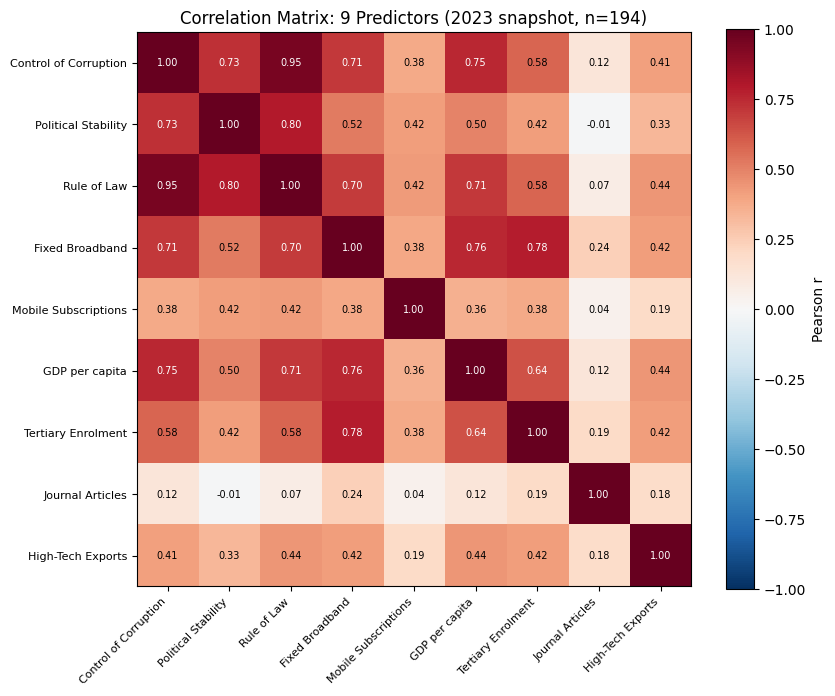


Saved plot_predictor_correlation_heatmap.png
Saved predictor_correlation_matrix.csv, predictor_correlation_flagged_pairs.csv, predictor_vif.csv


In [24]:
# ============================================================
# Bivariate analysis: correlation matrix + multicollinearity
# check among the 9 predictors, using the 2023 snapshot
# (imputed dataset) -- prerequisite check before RQ2 regression
# ============================================================

imputed = pd.read_csv(DATA_DIR + 'processed/analytic_dataset_imputed.csv')
snapshot_2023 = imputed[imputed['predictor_year'] == 2023].drop_duplicates(subset='iso3')

PREDICTOR_COLS = [
    'GOV_WGI_CC_EST', 'GOV_WGI_PV_EST', 'GOV_WGI_RL_EST',
    'IT.NET.BBND.P2', 'IT.CEL.SETS.P2', 'NY.GDP.PCAP.PP.CD',
    'SE.TER.ENRR', 'IP.JRN.ARTC.SC', 'TX.VAL.TECH.MF.ZS',
]
LABELS = {
    'GOV_WGI_CC_EST': 'Control of Corruption', 'GOV_WGI_PV_EST': 'Political Stability',
    'GOV_WGI_RL_EST': 'Rule of Law', 'IT.NET.BBND.P2': 'Fixed Broadband',
    'IT.CEL.SETS.P2': 'Mobile Subscriptions', 'NY.GDP.PCAP.PP.CD': 'GDP per capita',
    'SE.TER.ENRR': 'Tertiary Enrolment', 'IP.JRN.ARTC.SC': 'Journal Articles',
    'TX.VAL.TECH.MF.ZS': 'High-Tech Exports',
}

X = snapshot_2023[PREDICTOR_COLS].rename(columns=LABELS)
print(f"n = {len(X)} countries (2023 snapshot, imputed)")

# ------------------------------------------------------------
# Pearson correlation matrix
# ------------------------------------------------------------
corr = X.corr(method='pearson')
print("\n=== CORRELATION MATRIX ===")
pd.set_option('display.width', 160)
print(corr.round(2))

# ------------------------------------------------------------
# Flag pairs above |r| > 0.7 (common multicollinearity concern
# threshold) -- excluding the diagonal
# ------------------------------------------------------------
print("\n=== PREDICTOR PAIRS WITH |r| > 0.7 ===")
pairs = []
cols = corr.columns.tolist()
for i in range(len(cols)):
    for j in range(i + 1, len(cols)):
        r = corr.iloc[i, j]
        if abs(r) > 0.7:
            pairs.append({'predictor_1': cols[i], 'predictor_2': cols[j], 'r': r})
pairs_df = pd.DataFrame(pairs).sort_values('r', key=abs, ascending=False)
if len(pairs_df):
    print(pairs_df.to_string(index=False))
else:
    print("None found.")

# ------------------------------------------------------------
# Variance Inflation Factor (VIF) -- more rigorous than pairwise
# correlation alone, since it captures multicollinearity
# involving 3+ predictors jointly, not just pairs
# ------------------------------------------------------------
print("\n=== VARIANCE INFLATION FACTORS ===")
X_vif = X.copy()
X_vif.insert(0, 'const', 1.0)  # VIF calculation requires a constant term
vif_data = pd.DataFrame({
    'predictor': X.columns,
    'VIF': [variance_inflation_factor(X_vif.values, i + 1) for i in range(len(X.columns))]
}).sort_values('VIF', ascending=False)
print(vif_data.to_string(index=False))
print("\n(Common rule of thumb: VIF > 5 warrants attention, VIF > 10 is a serious concern.)")

# ------------------------------------------------------------
# Heatmap visualization
# ------------------------------------------------------------
fig, ax = plt.subplots(figsize=(8.5, 7))
im = ax.imshow(corr, cmap='RdBu_r', vmin=-1, vmax=1)
ax.set_xticks(range(len(cols)))
ax.set_yticks(range(len(cols)))
ax.set_xticklabels(cols, rotation=45, ha='right', fontsize=8)
ax.set_yticklabels(cols, fontsize=8)
for i in range(len(cols)):
    for j in range(len(cols)):
        val = corr.iloc[i, j]
        color = 'white' if abs(val) > 0.6 else 'black'
        ax.text(j, i, f'{val:.2f}', ha='center', va='center', color=color, fontsize=7)
plt.colorbar(im, label='Pearson r')
ax.set_title('Correlation Matrix: 9 Predictors (2023 snapshot, n=%d)' % len(X))
plt.tight_layout()
plt.savefig(DATA_DIR + 'processed/plot_predictor_correlation_heatmap.png', dpi=150)
plt.show()
plt.close()
print("\nSaved plot_predictor_correlation_heatmap.png")

corr.to_csv(DATA_DIR + 'processed/predictor_correlation_matrix.csv')
pairs_df.to_csv(DATA_DIR + 'processed/predictor_correlation_flagged_pairs.csv', index=False)
vif_data.to_csv(DATA_DIR + 'processed/predictor_vif.csv', index=False)
print("Saved predictor_correlation_matrix.csv, predictor_correlation_flagged_pairs.csv, predictor_vif.csv")

In [25]:
#DATA_DIR + 'processed/

In [26]:
# ============================================================
# RQ1 Descriptive Analysis
#   A. Mean rank / rank stability, 2021-2024 (pre-2025 era only)
#      -- both raw rank and percentile rank (accounts for the
#         roster growing from 160 to 195 countries over time)
#   B. Annual tier classification (Top/Mid/Bottom by within-year
#      percentile of readiness_score)
#   C. Identify high-performing, stable countries
#   D. 2024 vs 2025 comparison -- did the methodology change
#      cause a systematic shift in percentile rank?
# ============================================================
gari = pd.read_csv(DATA_DIR + 'processed/gari_readiness_long_iso3.csv')

# ------------------------------------------------------------
# Roster size per year (needed for percentile rank)
# ------------------------------------------------------------
roster_size = gari.groupby('year')['iso3'].nunique()
print("Roster size per year:")
print(roster_size)

gari = gari.merge(roster_size.rename('n_countries_that_year'), on='year')
gari['percentile_rank'] = gari['readiness_rank'] / gari['n_countries_that_year']
# lower percentile_rank = better (rank 1 -> near 0); flip so higher = better, more intuitive
gari['percentile_rank_higher_is_better'] = 1 - gari['percentile_rank']

# ============================================================
# A. Mean rank / stability, 2021-2024 only (pre-2025 era)
# ============================================================
pre2025 = gari[gari['year'].between(2021, 2024)].copy()

stability = (
    pre2025.groupby('iso3')
    .agg(
        country_name=('country_raw', 'first'),
        n_years=('year', 'nunique'),
        mean_raw_rank=('readiness_rank', 'mean'),
        sd_raw_rank=('readiness_rank', 'std'),
        mean_percentile_rank=('percentile_rank_higher_is_better', 'mean'),
        sd_percentile_rank=('percentile_rank_higher_is_better', 'std'),
        mean_score=('readiness_score', 'mean'),
    )
    .reset_index()
)

n_partial = (stability['n_years'] < 4).sum()
print(f"\nCountries with all 4 years (2021-2024) present: {(stability['n_years']==4).sum()}")
print(f"Countries with fewer than 4 years (SD less reliable): {n_partial}")



Roster size per year:
year
2021    160
2022    181
2023    193
2024    188
2025    195
Name: iso3, dtype: int64

Countries with all 4 years (2021-2024) present: 160
Countries with fewer than 4 years (SD less reliable): 33


In [27]:
#gari[gari['country_raw'] == 'United States of America']

In [28]:
# ============================================================
# B. Annual tier classification (Top/Mid/Bottom by within-year
#    percentile of readiness_score, all 5 years)
#
# Uses groupby().transform() rather than groupby().apply() --
# apply() with a function returning the same column set as the
# input silently drops the grouping column in this pandas
# version (confirmed via isolated test), which is a fragile
# pattern worth avoiding regardless of version.
# ============================================================
gari['score_percentile_within_year'] = gari.groupby('year')['readiness_score'].rank(pct=True)

def bin_tier(p):
    if p >= 2 / 3:
        return 'Top'
    elif p >= 1 / 3:
        return 'Mid'
    else:
        return 'Bottom'

gari['tier'] = gari['score_percentile_within_year'].apply(bin_tier)

print("\nTier counts per year:")
print(gari.groupby(['year', 'tier'], observed=True).size().unstack())




Tier counts per year:
tier  Bottom  Mid  Top
year                  
2021      53   53   54
2022      60   60   61
2023      64   64   65
2024      62   63   63
2025      64   65   66


In [29]:
# ============================================================
# C. High-performing AND stable countries (2021-2024)
#    Defined as: top-third mean percentile rank AND
#    bottom-third (i.e., lowest/most stable) SD of percentile rank
# ============================================================
complete = stability[stability['n_years'] == 4].copy()  # require full data for fair stability comparison

perf_cutoff = complete['mean_percentile_rank'].quantile(0.67)
stability_cutoff = complete['sd_percentile_rank'].quantile(0.33)

top_stable = complete[
    (complete['mean_percentile_rank'] >= perf_cutoff) &
    (complete['sd_percentile_rank'] <= stability_cutoff)
].sort_values('mean_percentile_rank', ascending=False)

print(f"\n=== TOP-PERFORMING AND STABLE COUNTRIES (2021-2024, n={len(top_stable)}) ===")
print(top_stable[['country_name', 'mean_percentile_rank', 'sd_percentile_rank', 'mean_score']].to_string(index=False))




=== TOP-PERFORMING AND STABLE COUNTRIES (2021-2024, n=28) ===
            country_name  mean_percentile_rank  sd_percentile_rank  mean_score
United States of America              0.994431            0.000476   86.427326
               Singapore              0.988862            0.000951   83.198370
          United Kingdom              0.980634            0.005002   79.311630
                 Finland              0.971076            0.012757   77.669232
                  Canada              0.967701            0.008041   77.591051
             Netherlands              0.956113            0.011487   76.329474
                   Japan              0.941204            0.013142   75.564033
               Australia              0.938233            0.018660   75.259373
                 Denmark              0.936549            0.011069   75.093051
                  Sweden              0.935917            0.017757   74.794457
                  Norway              0.931646            0.009459  

In [30]:
# ============================================================
# D. 2024 vs 2025: did the methodology change shift rankings?
# ============================================================
y2024 = gari[gari['year'] == 2024][['iso3', 'percentile_rank_higher_is_better']].rename(
    columns={'percentile_rank_higher_is_better': 'pct_rank_2024'})
y2025 = gari[gari['year'] == 2025][['iso3', 'percentile_rank_higher_is_better']].rename(
    columns={'percentile_rank_higher_is_better': 'pct_rank_2025'})

compare = y2024.merge(y2025, on='iso3', how='inner')
compare['shift'] = compare['pct_rank_2025'] - compare['pct_rank_2024']

print(f"\n=== 2024 vs 2025 PERCENTILE RANK COMPARISON (n={len(compare)} countries in both years) ===")
print(f"Mean shift: {compare['shift'].mean():.4f}")
print(f"Median shift: {compare['shift'].median():.4f}")
print(f"SD of shift: {compare['shift'].std():.4f}")

# Paired tests: is the shift systematically different from zero?
t_stat, t_p = stats.ttest_rel(compare['pct_rank_2025'], compare['pct_rank_2024'])
w_stat, w_p = stats.wilcoxon(compare['pct_rank_2025'], compare['pct_rank_2024'])
print(f"\nPaired t-test:      t={t_stat:.3f}, p={t_p:.4f}")
print(f"Wilcoxon signed-rank: W={w_stat:.3f}, p={w_p:.4f}")

print("\nLargest positive shifts (most improved under 2025 methodology):")
name_lookup = gari[['iso3', 'country_raw']].drop_duplicates(subset='iso3')  # one name per country, avoids
                                                                              # duplicate rows from capitalization
                                                                              # variants like "Côte D'Ivoire" vs
                                                                              # "Côte d'Ivoire" both mapping to CIV
print(compare.merge(name_lookup, on='iso3')
      .nlargest(10, 'shift')[['iso3','country_raw','pct_rank_2024','pct_rank_2025','shift']]
      .to_string(index=False))

print("\nLargest negative shifts (most declined under 2025 methodology):")
print(compare.merge(name_lookup, on='iso3')
      .nsmallest(10, 'shift')[['iso3','country_raw','pct_rank_2024','pct_rank_2025','shift']]
      .to_string(index=False))

# ------------------------------------------------------------
# Save outputs
# ------------------------------------------------------------
stability.to_csv(DATA_DIR + 'processed/rq1_rank_stability_2021_2024.csv', index=False)
top_stable.to_csv(DATA_DIR + 'processed/rq1_top_performing_stable_countries.csv', index=False)
compare.to_csv(DATA_DIR + 'processed/rq1_2024_vs_2025_comparison.csv', index=False)
gari.to_csv(DATA_DIR + 'processed/gari_readiness_long_with_tiers.csv', index=False)
print("\nSaved: rq1_rank_stability_2021_2024.csv, rq1_top_performing_stable_countries.csv, "
      "rq1_2024_vs_2025_comparison.csv, gari_readiness_long_with_tiers.csv")


=== 2024 vs 2025 PERCENTILE RANK COMPARISON (n=188 countries in both years) ===
Mean shift: 0.0113
Median shift: 0.0113
SD of shift: 0.1069

Paired t-test:      t=1.453, p=0.1479
Wilcoxon signed-rank: W=7598.000, p=0.0854

Largest positive shifts (most improved under 2025 methodology):
iso3                      country_raw  pct_rank_2024  pct_rank_2025    shift
 TZA      United Republic of Tanzania       0.260638       0.523077 0.262439
 CIV                    Côte D'Ivoire       0.255319       0.512821 0.257501
 NPL                            Nepal       0.202128       0.456410 0.254283
 SLV                      El Salvador       0.228723       0.466667 0.237943
 AZE                       Azerbaijan       0.409574       0.646154 0.236579
 COD Democratic Republic of the Congo       0.037234       0.261538 0.224304
 NAM                          Namibia       0.212766       0.435897 0.223131
 ECU                          Ecuador       0.446809       0.661538 0.214730
 LSO               

###Peer-group Imputation

In [31]:
# ============================================================
# Peer-group (Region x Income x predictor_year) mean imputation
# for the 9 WDI/WGI predictors in analytic_dataset_merged.csv
#
# Applied to a COPY of the merged dataset -- the merged file
# itself stays untouched as the source-of-truth artifact.
#
# Imputation is computed separately per predictor_year (not
# pooled across years), consistent with the original EDA plan.
# ============================================================
df = pd.read_csv(DATA_DIR + 'processed/analytic_dataset_merged.csv')

PREDICTOR_COLS = [
    'GOV_WGI_CC_EST', 'GOV_WGI_PV_EST', 'GOV_WGI_RL_EST',
    'IT.NET.BBND.P2', 'IT.CEL.SETS.P2', 'NY.GDP.PCAP.PP.CD',
    'SE.TER.ENRR', 'IP.JRN.ARTC.SC', 'TX.VAL.TECH.MF.ZS',
]

print(f"Starting rows: {len(df)}")
print(f"Missing values before imputation, per predictor:")
print(df[PREDICTOR_COLS].isna().sum())

# ------------------------------------------------------------
# Step 1: check peer-group (region x income x predictor_year)
# cell sizes and how many non-missing values each cell actually
# has per predictor -- BEFORE imputing anything
# ------------------------------------------------------------
group_cols = ['predictor_year', 'region', 'income_classification']

print("\n=== PEER GROUP SIZE CHECK ===")
group_sizes = df.groupby(group_cols).size().reset_index(name='n_countries_in_group')
print(f"Total peer groups (region x income x predictor_year): {len(group_sizes)}")
print(f"Smallest groups (most at-risk for unreliable means):")
print(group_sizes.sort_values('n_countries_in_group').head(10).to_string(index=False))

# For each predictor, how many groups have FEWER than 2 non-missing
# values to compute a mean from? (a group with 0 non-missing can't
# be imputed at all; 1 non-missing produces a mean equal to a single
# country's value, which is a weak basis for imputing others)
print("\n=== GROUPS WITH <2 NON-MISSING VALUES, PER PREDICTOR ===")
risky_groups_summary = []
for col in PREDICTOR_COLS:
    non_missing_counts = (
        df.groupby(group_cols)[col]
        .apply(lambda s: s.notna().sum())
        .reset_index(name='n_non_missing')
    )
    risky = non_missing_counts[non_missing_counts['n_non_missing'] < 2]
    risky_groups_summary.append({'predictor': col, 'n_risky_groups': len(risky)})
    if len(risky):
        print(f"\n{col}: {len(risky)} groups with <2 non-missing values")
        print(risky.to_string(index=False))

risky_df = pd.DataFrame(risky_groups_summary)
print("\nSummary:")
print(risky_df.to_string(index=False))

# ------------------------------------------------------------
# Step 2: apply peer-group mean imputation, with a fallback for
# groups that don't have enough data: fall back to
# (income_classification x predictor_year) mean, dropping region,
# and if THAT still fails, fall back to (predictor_year) global mean
# ------------------------------------------------------------
df_imputed = df.copy()

for col in PREDICTOR_COLS:
    flag_col = f'{col}_imputed'
    level_col = f'{col}_impute_level'
    df_imputed[flag_col] = df_imputed[col].isna()
    df_imputed[level_col] = np.where(df_imputed[col].notna(), 'observed', None)

    # Level 1: region x income x year peer group mean
    level1_means = df.groupby(group_cols)[col].transform('mean')
    was_missing = df_imputed[col].isna()
    df_imputed[col] = df_imputed[col].fillna(level1_means)
    filled_at_level1 = was_missing & df_imputed[col].notna()
    df_imputed.loc[filled_at_level1, level_col] = 'region_income_year'

    # Level 2 fallback: income x year mean (drop region), for
    # anything still missing after level 1
    still_missing = df_imputed[col].isna()
    if still_missing.any():
        level2_means = df.groupby(['predictor_year', 'income_classification'])[col].transform('mean')
        was_missing = still_missing.copy()
        df_imputed.loc[still_missing, col] = level2_means[still_missing]
        filled_at_level2 = was_missing & df_imputed[col].notna()
        df_imputed.loc[filled_at_level2, level_col] = 'income_year_only'

    # Level 3 fallback: predictor_year global mean, for anything
    # still missing after level 2
    still_missing = df_imputed[col].isna()
    if still_missing.any():
        level3_means = df.groupby(['predictor_year'])[col].transform('mean')
        was_missing = still_missing.copy()
        df_imputed.loc[still_missing, col] = level3_means[still_missing]
        filled_at_level3 = was_missing & df_imputed[col].notna()
        df_imputed.loc[filled_at_level3, level_col] = 'year_global'

    still_missing = df_imputed[col].isna()
    if still_missing.any():
        print(f"\nWARNING: {col} still has {still_missing.sum()} missing values "
              f"after all fallback levels -- these countries have no peer data at all.")

# ------------------------------------------------------------
# Step 2b: how many imputed values relied on a THIN peer group
# (only 1 non-missing donor) vs. a genuine multi-country average?
# ------------------------------------------------------------
print("\n=== IMPUTATION FALLBACK LEVEL BREAKDOWN ===")
for col in PREDICTOR_COLS:
    level_col = f'{col}_impute_level'
    counts = df_imputed[level_col].value_counts()
    print(f"\n{col}:")
    print(counts.to_string())

# ------------------------------------------------------------
# Step 3: summary of what got imputed, and at which fallback level
# ------------------------------------------------------------
print("\n=== IMPUTATION SUMMARY ===")
for col in PREDICTOR_COLS:
    flag_col = f'{col}_imputed'
    n_imputed = df_imputed[flag_col].sum()
    pct = n_imputed / len(df_imputed) * 100
    print(f"{col}: {n_imputed} values imputed ({pct:.1f}% of {len(df_imputed)} rows)")

print(f"\nRemaining missing values after imputation:")
print(df_imputed[PREDICTOR_COLS].isna().sum())

# ------------------------------------------------------------
# Save
# ------------------------------------------------------------
df_imputed.to_csv(DATA_DIR + 'processed/analytic_dataset_imputed.csv', index=False)
group_sizes.to_csv(DATA_DIR + 'processed/imputation_peer_group_sizes.csv', index=False)
risky_df.to_csv(DATA_DIR + 'processed/imputation_risky_groups_summary.csv', index=False)
print("\nSaved: analytic_dataset_imputed.csv, imputation_peer_group_sizes.csv, "
      "imputation_risky_groups_summary.csv")

Starting rows: 753
Missing values before imputation, per predictor:
GOV_WGI_CC_EST         4
GOV_WGI_PV_EST         4
GOV_WGI_RL_EST         4
IT.NET.BBND.P2        61
IT.CEL.SETS.P2        52
NY.GDP.PCAP.PP.CD     29
SE.TER.ENRR          276
IP.JRN.ARTC.SC         0
TX.VAL.TECH.MF.ZS    131
dtype: int64

=== PEER GROUP SIZE CHECK ===
Total peer groups (region x income x predictor_year): 65
Smallest groups (most at-risk for unreliable means):
 predictor_year              region income_classification  n_countries_in_group
           2021          South Asia            Low income                     1
           2022 East Asia & Pacific            Low income                     1
           2021  Sub-Saharan Africa           High income                     1
           2021          South Asia   Upper middle income                     1
           2023 East Asia & Pacific            Low income                     1
           2022          South Asia            Low income                

###Hyphotheis Testing

In [32]:
# ============================================================
# RQ1 Hypothesis Test (H0_1 / H1_1)
#   Group comparison: Top-Stable (n=28) vs. Rest (n=132)
#   on all 9 governance/socioeconomic/technological predictors
#
# NOTE ON SAMPLE SIZE: Table 1's power analysis specified 63
# per group (126 total) for d=0.5, power=0.80, alpha=0.05.
# The true Top-Stable group (per RQ1's "highest AND most
# stable" definition) is only 28 countries. This test is
# therefore UNDERPOWERED relative to the original design --
# reported explicitly below, not hidden. A non-significant
# result should be read as inconclusive (possible Type II
# error), not as evidence of no difference. A significant
# result, conversely, is a strong finding given the reduced
# power.
#
# NOTE ON PREDICTOR SNAPSHOT: uses each country's 2023
# predictor values (era=0, the 2023->2024 pair) as the
# representative "current characteristics" snapshot -- the
# most recent, most complete pre-2025 predictor data available.
# ============================================================

imputed = pd.read_csv(DATA_DIR + 'processed/analytic_dataset_imputed.csv')
top_stable = pd.read_csv(DATA_DIR + 'processed/rq1_top_performing_stable_countries.csv')
stability = pd.read_csv(DATA_DIR + 'processed/rq1_rank_stability_2021_2024.csv')

PREDICTOR_COLS = [
    'GOV_WGI_CC_EST', 'GOV_WGI_PV_EST', 'GOV_WGI_RL_EST',
    'IT.NET.BBND.P2', 'IT.CEL.SETS.P2', 'NY.GDP.PCAP.PP.CD',
    'SE.TER.ENRR', 'IP.JRN.ARTC.SC', 'TX.VAL.TECH.MF.ZS',
]
PREDICTOR_LABELS = {
    'GOV_WGI_CC_EST': 'Control of Corruption',
    'GOV_WGI_PV_EST': 'Political Stability & Absence of Violence',
    'GOV_WGI_RL_EST': 'Rule of Law',
    'IT.NET.BBND.P2': 'Fixed Broadband Subscriptions',
    'IT.CEL.SETS.P2': 'Mobile Cellular Subscriptions',
    'NY.GDP.PCAP.PP.CD': 'GDP per capita, PPP',
    'SE.TER.ENRR': 'Tertiary Enrolment',
    'IP.JRN.ARTC.SC': 'Scientific & Technical Journal Articles',
    'TX.VAL.TECH.MF.ZS': 'High-Technology Exports',
}

# ------------------------------------------------------------
# Build the 2023-snapshot predictor table (one row per country)
# ------------------------------------------------------------
snapshot_2023 = imputed[imputed['predictor_year'] == 2023].drop_duplicates(subset='iso3')
print(f"Countries with a 2023 predictor snapshot: {len(snapshot_2023)}")

# ------------------------------------------------------------
# Define groups: Top-Stable (28) vs. Rest (complete-data
# countries not in the Top-Stable set)
# ------------------------------------------------------------
top_stable_codes = set(top_stable['iso3'])
complete_codes = set(stability[stability['n_years'] == 4]['iso3'])
rest_codes = complete_codes - top_stable_codes

group_data = snapshot_2023[snapshot_2023['iso3'].isin(complete_codes)].copy()
group_data['group'] = np.where(group_data['iso3'].isin(top_stable_codes), 'Top-Stable', 'Rest')

n_top = (group_data['group'] == 'Top-Stable').sum()
n_rest = (group_data['group'] == 'Rest').sum()
print(f"Top-Stable group: {n_top} countries")
print(f"Rest group: {n_rest} countries")
print(f"(Countries lost to missing 2023 snapshot: {len(complete_codes) - len(group_data)})")

# ------------------------------------------------------------
# Run Welch's t-test (does not assume equal variances --
# appropriate given the unequal group sizes) for each predictor
# ------------------------------------------------------------
results = []
for col in PREDICTOR_COLS:
    top_vals = group_data.loc[group_data['group'] == 'Top-Stable', col].dropna()
    rest_vals = group_data.loc[group_data['group'] == 'Rest', col].dropna()

    t_stat, p_val = stats.ttest_ind(top_vals, rest_vals, equal_var=False)

    # Cohen's d (using pooled SD for effect size, standard convention)
    pooled_sd = np.sqrt(((len(top_vals) - 1) * top_vals.std()**2 +
                          (len(rest_vals) - 1) * rest_vals.std()**2) /
                         (len(top_vals) + len(rest_vals) - 2))
    cohens_d = (top_vals.mean() - rest_vals.mean()) / pooled_sd

    results.append({
        'predictor': col,
        'label': PREDICTOR_LABELS[col],
        'top_stable_mean': top_vals.mean(),
        'top_stable_sd': top_vals.std(),
        'rest_mean': rest_vals.mean(),
        'rest_sd': rest_vals.std(),
        't_stat': t_stat,
        'p_value': p_val,
        'cohens_d': cohens_d,
        'significant_at_05': p_val < 0.05,
        'significant_at_bonferroni': p_val < (0.05 / len(PREDICTOR_COLS)),
    })

results_df = pd.DataFrame(results).sort_values('p_value')

print("\n=== GROUP COMPARISON RESULTS (sorted by p-value) ===")
pd.set_option('display.width', 160)
pd.set_option('display.max_columns', None)
print(results_df[['label', 'top_stable_mean', 'rest_mean', 't_stat', 'p_value',
                   'cohens_d', 'significant_at_05', 'significant_at_bonferroni']].to_string(index=False))

n_sig_uncorrected = results_df['significant_at_05'].sum()
n_sig_bonferroni = results_df['significant_at_bonferroni'].sum()
print(f"\nSignificant at uncorrected alpha=0.05: {n_sig_uncorrected} of {len(PREDICTOR_COLS)} predictors")
print(f"Significant after Bonferroni correction (alpha={0.05/len(PREDICTOR_COLS):.4f}): {n_sig_bonferroni} of {len(PREDICTOR_COLS)} predictors")

# ------------------------------------------------------------
# Power note, printed explicitly
# ------------------------------------------------------------
print(f"\n=== POWER NOTE ===")
print(f"Table 1 specified 63 per group (126 total) for d=0.5, power=0.80, alpha=0.05.")
print(f"Actual groups: Top-Stable n={n_top}, Rest n={n_rest}.")
print(f"This test is underpowered relative to the original design for the smaller group.")
print(f"Non-significant results here should be treated as inconclusive, not as evidence of no effect.")

results_df.to_csv(DATA_DIR + 'processed/rq1_hypothesis_test_results.csv', index=False)
group_data.to_csv(DATA_DIR + 'processed/rq1_group_comparison_data.csv', index=False)
print("\nSaved: rq1_hypothesis_test_results.csv, rq1_group_comparison_data.csv")

Countries with a 2023 predictor snapshot: 194
Top-Stable group: 27 countries
Rest group: 132 countries
(Countries lost to missing 2023 snapshot: 1)

=== GROUP COMPARISON RESULTS (sorted by p-value) ===
                                    label  top_stable_mean    rest_mean    t_stat      p_value  cohens_d  significant_at_05  significant_at_bonferroni
            Fixed Broadband Subscriptions        34.737374    14.014550 10.071483 2.700645e-14  1.575477               True                       True
                       Tertiary Enrolment        78.334568    40.550574  9.471336 5.300936e-14  1.377387               True                       True
                    Control of Corruption         1.113170    -0.281051  7.796156 2.553291e-09  1.667899               True                       True
                              Rule of Law         1.015693    -0.336323  7.714521 3.088609e-09  1.636311               True                       True
Political Stability & Absence of Violence  

##RQ2

####Bivariate correlations by era

In [33]:
# ============================================================
# PART A: Bivariate correlations, by era
# ============================================================
print("\n" + "="*70)
print("PART A: BIVARIATE CORRELATIONS (readiness_score vs. each predictor)")
print("="*70)

corr_results = []
for era, era_label in [(0, 'Pre-2025'), (1, '2025')]:
    era_df = imputed[imputed['era'] == era]
    for col in PREDICTOR_COLS:
        r, p = stats.pearsonr(era_df[col], era_df['readiness_score'])
        corr_results.append({
            'era': era_label, 'predictor': LABELS[col], 'r': r, 'p_value': p,
            'n': len(era_df)
        })

corr_df = pd.DataFrame(corr_results)
pivot_corr = corr_df.pivot(index='predictor', columns='era', values='r').round(3)
pivot_p = corr_df.pivot(index='predictor', columns='era', values='p_value')
print("\nCorrelation (r) with readiness_score, by era:")
print(pivot_corr.sort_values('Pre-2025', ascending=False))


PART A: BIVARIATE CORRELATIONS (readiness_score vs. each predictor)

Correlation (r) with readiness_score, by era:
era                     2025  Pre-2025
predictor                             
Fixed Broadband        0.661     0.784
GDP per capita         0.680     0.774
Rule of Law            0.598     0.752
Control of Corruption  0.616     0.748
Tertiary Enrolment     0.684     0.748
Political Stability    0.268     0.488
Mobile Subscriptions   0.344     0.486
High-Tech Exports      0.441     0.478
Journal Articles       0.340     0.334


####Multple Regressions separate models by era

The formula variable in the highlighted cell is a string that defines the structure of your Ordinary Least Squares (OLS) regression model. It's used by the statsmodels.formula.api.ols function to specify which variables are the dependent (outcome) variable and which are the independent (predictor) variables.

Here's a breakdown of what it's doing:

'readiness_score': This is the dependent variable (the outcome you're trying to predict or explain).
~: This symbol separates the dependent variable from the independent variables.
' + '.join([f'Q("{c}")' for c in PREDICTOR_COLS]): This part constructs a string of all your predictor variables. Let's break it down further:
PREDICTOR_COLS: This is a list of column names that you want to use as independent variables in your regression.
f'Q("{c}")': For each column c in PREDICTOR_COLS, it formats the column name as Q("column_name"). The Q() function is crucial in statsmodels formulas, as it allows you to use column names that might contain special characters, spaces, or conflict with Python keywords, ensuring they are treated as literal variable names.
' + '.join(...): This joins all the formatted predictor column names with a + sign, creating a single string like "Q("GOV_WGI_CC_EST") + Q("GOV_WGI_PV_EST") + ...".
So, in essence, the formula variable creates a human-readable (and statsmodels-interpretable) representation of your regression equation, allowing ols to know that readiness_score is being modeled as a linear combination of the variables listed in PREDICTOR_COLS.

In [34]:
# ============================================================
# PART B: Multiple regression, separate models per era
#          -- clustered SEs by country for era 0 (repeated obs)
# ============================================================
print("\n" + "="*70)
print("PART B: MULTIPLE REGRESSION, SEPARATE MODELS PER ERA")
print("="*70)

formula = 'readiness_score ~ ' + ' + '.join([f'Q("{c}")' for c in PREDICTOR_COLS])

models = {}
for era, era_label in [(0, 'Pre-2025 (2021-2024)'), (1, '2025')]:
    era_df = imputed[imputed['era'] == era].copy()
    model = smf.ols(formula, data=era_df).fit(
        cov_type='cluster', cov_kwds={'groups': era_df['iso3']}
    )
    models[era] = model
    print(f"\n--- {era_label} (n={len(era_df)}, clustered SE by country) ---")
    print(f"R-squared: {model.rsquared:.4f}  |  Adj. R-squared: {model.rsquared_adj:.4f}")
    coef_table = pd.DataFrame({
        'coef': model.params,
        'std_err': model.bse,
        't': model.tvalues,
        'p_value': model.pvalues,
    })
    coef_table.index = ['Intercept'] + [LABELS[c] for c in PREDICTOR_COLS]
    print(coef_table.round(4).to_string())

# ============================================================
# Fits Model: Uses statsmodels.formula.api.ols to fit an Ordinary Least Squares (OLS) regression model.
# cov_type='cluster' with groups=era_df['iso3'] to calculate standard
# errors that account for the fact that observations from the same country
# (identified by iso3) are not independent,
# especially in the 'Pre-2025' era where there are multiple observations per country.
# ============================================================


PART B: MULTIPLE REGRESSION, SEPARATE MODELS PER ERA

--- Pre-2025 (2021-2024) (n=559, clustered SE by country) ---
R-squared: 0.8288  |  Adj. R-squared: 0.8260
                          coef  std_err        t  p_value
Intercept              25.3335   1.9970  12.6857   0.0000
Control of Corruption  -0.8331   1.5141  -0.5502   0.5822
Political Stability    -4.1758   0.8545  -4.8867   0.0000
Rule of Law             8.6978   1.6746   5.1941   0.0000
Fixed Broadband         0.0615   0.0709   0.8685   0.3851
Mobile Subscriptions    0.0612   0.0166   3.6837   0.0002
GDP per capita          0.0002   0.0000   5.6824   0.0000
Tertiary Enrolment      0.1490   0.0261   5.7036   0.0000
Journal Articles        0.0000   0.0000   3.4718   0.0005
High-Tech Exports       0.1404   0.0528   2.6573   0.0079

--- 2025 (n=194, clustered SE by country) ---
R-squared: 0.7016  |  Adj. R-squared: 0.6870
                          coef  std_err       t  p_value
Intercept              22.0851   2.9991  7.3640   0

####Standardised coefficients

Part B's original code (unstandardized, for the significance/coefficient-interpretation table, Table 9's significance values) → then this new script right after it (for the standardized comparison table and Figure 5's chart). Both outputs are legitimate and both get used in the write-up — Table 9 in the report actually already reports the standardized values I noted, so to be precise: the standardized script is what actually generated the numbers in Table 9 and Figure 5, while Part B's raw-unit output is what you'd cite if anyone asks for the coefficients in their original, real-world units (e.g., "a one-subscription-per-100-people increase in broadband is associated with X change in score").

Check: standardized columns should have mean~0, SD~1
      GOV_WGI_CC_EST  GOV_WGI_PV_EST  IT.NET.BBND.P2  IT.CEL.SETS.P2  NY.GDP.PCAP.PP.CD  SE.TER.ENRR  IP.JRN.ARTC.SC  TX.VAL.TECH.MF.ZS  readiness_score
mean             0.0             0.0             0.0            -0.0               -0.0          0.0            -0.0                0.0              0.0
std              1.0             1.0             1.0             1.0                1.0          1.0             1.0                1.0              1.0

Pre-2025 standardized model: R-squared = 0.8107

2025 standardized model: R-squared = 0.6820

=== STANDARDIZED COEFFICIENTS (comparable across predictors) ===
                       Pre-2025   2025
Political Stability      -0.128 -0.378
Fixed Broadband           0.080 -0.012
High-Tech Exports         0.103  0.106
Mobile Subscriptions      0.128  0.107
Journal Articles          0.151  0.185
GDP per capita            0.236  0.264
Tertiary Enrolment        0.271  0.371
Control of Corru

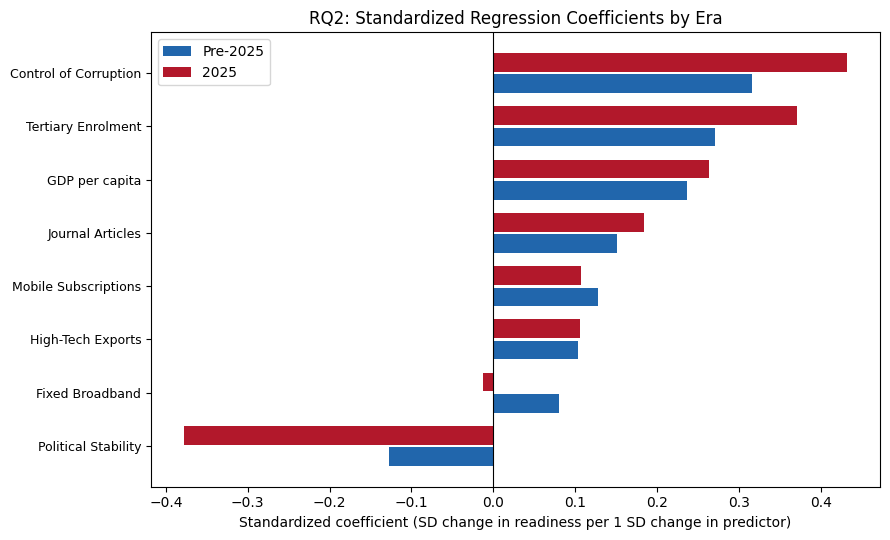

Saved plot_rq2_standardized_coefficients.png


In [35]:
# ============================================================
# RQ2: Standardized regression coefficients by era, + chart
#
# WHY STANDARDIZE: raw OLS coefficients aren't comparable across
# predictors with different units/scales (e.g. GDP per capita in
# USD vs. WGI estimates on a -2.5/2.5 scale). Standardizing both
# the predictors AND the outcome (z-score: subtract mean, divide
# by SD) puts every coefficient in the same unit: "SD change in
# readiness_score per 1 SD change in the predictor." This makes
# magnitudes directly comparable, which raw coefficients are not.
# ============================================================

PREDICTOR_COLS = [
    'GOV_WGI_CC_EST', 'GOV_WGI_PV_EST',
    'IT.NET.BBND.P2', 'IT.CEL.SETS.P2', 'NY.GDP.PCAP.PP.CD',
    'SE.TER.ENRR', 'IP.JRN.ARTC.SC', 'TX.VAL.TECH.MF.ZS',
]
LABELS = {
    'GOV_WGI_CC_EST': 'Control of Corruption', 'GOV_WGI_PV_EST': 'Political Stability',
    'IT.NET.BBND.P2': 'Fixed Broadband', 'IT.CEL.SETS.P2': 'Mobile Subscriptions',
    'NY.GDP.PCAP.PP.CD': 'GDP per capita', 'SE.TER.ENRR': 'Tertiary Enrolment',
    'IP.JRN.ARTC.SC': 'Journal Articles', 'TX.VAL.TECH.MF.ZS': 'High-Tech Exports',
}

# ------------------------------------------------------------
# Step 1: standardize (z-score) every predictor AND the outcome
# ------------------------------------------------------------
z = imputed.copy()
for col in PREDICTOR_COLS + ['readiness_score']:
    z[col] = (z[col] - z[col].mean()) / z[col].std()

print("Check: standardized columns should have mean~0, SD~1")
print(z[PREDICTOR_COLS + ['readiness_score']].agg(['mean', 'std']).round(3))

# ------------------------------------------------------------
# Step 2: re-run the same OLS regression as Part B, but on the
# standardized data, separately per era (clustered SE by country,
# same as the original models -- only the scale of the inputs
# has changed, not the modeling approach)
# ------------------------------------------------------------
formula = 'readiness_score ~ ' + ' + '.join([f'Q("{c}")' for c in PREDICTOR_COLS])

std_coefs = {}
for era, era_label in [(0, 'Pre-2025'), (1, '2025')]:
    era_df = z[z['era'] == era]
    model = smf.ols(formula, data=era_df).fit(
        cov_type='cluster', cov_kwds={'groups': era_df['iso3']}
    )
    std_coefs[era_label] = model.params.drop('Intercept')
    print(f"\n{era_label} standardized model: R-squared = {model.rsquared:.4f}")

# ------------------------------------------------------------
# Step 3: assemble into one table, sorted for readability
# ------------------------------------------------------------
std_df = pd.DataFrame(std_coefs)
std_df.index = [LABELS[c] for c in PREDICTOR_COLS]
std_df = std_df.sort_values('Pre-2025')

print("\n=== STANDARDIZED COEFFICIENTS (comparable across predictors) ===")
print(std_df.round(3).to_string())

std_df.to_csv(DATA_DIR + 'processed/rq2_standardized_coefficients.csv')
print("\nSaved rq2_standardized_coefficients.csv")

# ------------------------------------------------------------
# Step 4: horizontal grouped bar chart, Pre-2025 vs. 2025
# ------------------------------------------------------------
fig, ax = plt.subplots(figsize=(9, 5.5))
y = np.arange(len(std_df))
ax.barh(y - 0.2, std_df['Pre-2025'], height=0.35, label='Pre-2025', color='#2166ac')
ax.barh(y + 0.2, std_df['2025'], height=0.35, label='2025', color='#b2182b')
ax.axvline(0, color='black', linewidth=0.8)
ax.set_yticks(y)
ax.set_yticklabels(std_df.index, fontsize=9)
ax.set_xlabel('Standardized coefficient (SD change in readiness per 1 SD change in predictor)')
ax.set_title('RQ2: Standardized Regression Coefficients by Era')
ax.legend()
plt.tight_layout()
plt.savefig(DATA_DIR + 'processed/plot_rq2_standardized_coefficients.png', dpi=150)
plt.show()
plt.close()
print("Saved plot_rq2_standardized_coefficients.png")

####Pooled interaction model

Putting it together

So the two approaches aren't redundant — they answer two different questions that together give you the full picture:

Separate models: "what does the relationship look like, concretely, in each era?" (the actual coefficients, for interpretation and magnitude)
Interaction model: "is the difference between those two relationships statistically real, or could it just be sampling noise?" (the formal test)

In the previous cell, two separate models were run for each era, which inherently allowed the coefficients to differ. Here, by pooling all the data and including era as a main effect and interaction terms, you're directly testing whether the relationship between predictors and the readiness score changes depending on the era. This provides a more direct statistical test for differences across eras for each predictor, rather than just observing different coefficients in separate models.

In [36]:
# ============================================================
# PART C: Pooled interaction model -- direct test of H0_2b
#          (does the predictor-readiness relationship differ
#          by era?), also clustered by country
# ============================================================
print("\n" + "="*70)
print("PART C: POOLED MODEL WITH ERA x PREDICTOR INTERACTIONS (H0_2b test)")
print("="*70)

interaction_terms = ' + '.join([f'era:Q("{c}")' for c in PREDICTOR_COLS])
main_terms = ' + '.join([f'Q("{c}")' for c in PREDICTOR_COLS])
interaction_formula = f'readiness_score ~ era + {main_terms} + {interaction_terms}'

interaction_model = smf.ols(interaction_formula, data=imputed).fit(
    cov_type='cluster', cov_kwds={'groups': imputed['iso3']}
)

print(f"\nPooled model (n={len(imputed)}, clustered SE by country)")
print(f"R-squared: {interaction_model.rsquared:.4f}  |  Adj. R-squared: {interaction_model.rsquared_adj:.4f}")

interaction_summary = pd.DataFrame({
    'coef': interaction_model.params,
    'std_err': interaction_model.bse,
    't': interaction_model.tvalues,
    'p_value': interaction_model.pvalues,
})
print("\nInteraction terms only (era x predictor) -- a significant p-value here means",
      "\nthat predictor's association with readiness differs significantly by era:")
interaction_rows = [idx for idx in interaction_summary.index if 'era:' in idx]
interaction_display = interaction_summary.loc[interaction_rows].copy()
interaction_display.index = [LABELS[c] for c in PREDICTOR_COLS]
print(interaction_display.round(4).to_string())

n_sig_interactions = (interaction_display['p_value'] < 0.05).sum()
print(f"\n{n_sig_interactions} of {len(PREDICTOR_COLS)} predictors show a significantly "
      f"different relationship with readiness between eras (p<0.05).")

# ------------------------------------------------------------
# Save everything
# ------------------------------------------------------------
corr_df.to_csv(DATA_DIR + 'processed/rq2_bivariate_correlations.csv', index=False)
pd.concat([m.params.rename(f'era{e}_coef') for e, m in models.items()] +
          [m.pvalues.rename(f'era{e}_pvalue') for e, m in models.items()], axis=1).to_csv('rq2_regression_by_era.csv')
interaction_display.to_csv(DATA_DIR + 'processed/rq2_interaction_terms.csv')
print("\nSaved: rq2_bivariate_correlations.csv, rq2_regression_by_era.csv, rq2_interaction_terms.csv")


PART C: POOLED MODEL WITH ERA x PREDICTOR INTERACTIONS (H0_2b test)

Pooled model (n=753, clustered SE by country)
R-squared: 0.7730  |  Adj. R-squared: 0.7678

Interaction terms only (era x predictor) -- a significant p-value here means 
that predictor's association with readiness differs significantly by era:
                         coef  std_err       t  p_value
Control of Corruption  2.0622   0.8930  2.3093   0.0209
Political Stability   -4.5898   0.8051 -5.7009   0.0000
Fixed Broadband       -0.1062   0.0676 -1.5704   0.1163
Mobile Subscriptions  -0.0102   0.0176 -0.5786   0.5629
GDP per capita         0.0000   0.0000  0.6648   0.5062
Tertiary Enrolment     0.0590   0.0246  2.4015   0.0163
Journal Articles       0.0000   0.0000  2.8918   0.0038
High-Tech Exports      0.0037   0.0530  0.0692   0.9448

4 of 8 predictors show a significantly different relationship with readiness between eras (p<0.05).

Saved: rq2_bivariate_correlations.csv, rq2_regression_by_era.csv, rq2_interactio

##RQ3

In [37]:
# ============================================================
# RQ3: To what extent can national AI readiness be modelled
#      using regression and classification techniques, and
#      does performance differ pre-2025 vs. 2025 (H0_3a/H0_3b)?
#
# Design (as agreed):
#   - 8 predictors (Rule of Law excluded -- see RQ2 multicollinearity)
#   - Binary classification target: Top tier (top third by
#     within-year score percentile, from RQ1) vs. Rest
#   - GroupKFold (5-fold, grouped by country/iso3) cross-validation,
#     run SEPARATELY per era -- prevents leakage from the rolling-lag
#     design's repeated country observations in the pre-2025 era.
#     (2025 era has exactly 1 row/country already, so grouping is a
#     no-op there, but the same code path is used for consistency.)
#   - Regression task: Model 1 (Linear Regression, baseline) vs.
#     Model 3b (Random Forest Regressor)
#   - Classification task: Model 2 (Logistic Regression, baseline)
#     vs. Model 3a (Random Forest Classifier)
#   - A single grouped 80/20 split per era is ALSO produced, purely
#     for the confusion matrix / ROC curve visuals -- cross-validation
#     above is the primary performance estimate.
# ============================================================


imputed = pd.read_csv(DATA_DIR + 'processed/analytic_dataset_imputed.csv')
tiers = pd.read_csv(DATA_DIR + 'processed/gari_readiness_long_with_tiers.csv')

PREDICTOR_COLS = [
    'GOV_WGI_CC_EST', 'GOV_WGI_PV_EST',
    'IT.NET.BBND.P2', 'IT.CEL.SETS.P2', 'NY.GDP.PCAP.PP.CD',
    'SE.TER.ENRR', 'IP.JRN.ARTC.SC', 'TX.VAL.TECH.MF.ZS',
]  # Rule of Law deliberately excluded

# ------------------------------------------------------------
# Build the classification target: is this row's OUTCOME year
# a Top-tier result for that country? (merge on iso3 + outcome_year)
# ------------------------------------------------------------
df = imputed.merge(
    tiers[['iso3', 'year', 'tier']],
    left_on=['iso3', 'outcome_year'], right_on=['iso3', 'year'], how='left'
)
print(f"Rows before tier merge: {len(imputed)}, after: {len(df)}")
print(f"Missing tier after merge: {df['tier'].isna().sum()}")

df['is_top_tier'] = (df['tier'] == 'Top').astype(int)
print(f"\nClass balance (is_top_tier):")
print(df.groupby('era')['is_top_tier'].value_counts())

X_cols = PREDICTOR_COLS
results_summary = []



Rows before tier merge: 753, after: 753
Missing tier after merge: 0

Class balance (is_top_tier):
era  is_top_tier
0    0              373
     1              186
1    0              129
     1               65
Name: count, dtype: int64


load + build binary target → define the 8-predictor feature set → grouped 5-fold CV per era for both regression (Model 1 baseline vs. Random Forest) and classification (Model 2 baseline vs. Random Forest) → a final single grouped split per era for the confusion matrix/ROC visuals the rubric wants.

In [38]:
# ============================================================
# PART A: Grouped 5-fold cross-validation, per era, both tasks
# ============================================================
for era, era_label in [(0, 'Pre-2025'), (1, '2025')]:
    era_df = df[df['era'] == era].reset_index(drop=True)
    X = era_df[X_cols].values
    y_reg = era_df['readiness_score'].values
    y_clf = era_df['is_top_tier'].values
    groups = era_df['iso3'].values

    n_countries = era_df['iso3'].nunique()
    gkf = GroupKFold(n_splits=5)

    print(f"\n{'='*70}\n{era_label} (n={len(era_df)} rows, {n_countries} countries, 5 grouped folds)\n{'='*70}")

    # --- Regression task: Linear Regression vs Random Forest ---
    lr_rmse, lr_mae, lr_r2 = [], [], []
    rf_rmse, rf_mae, rf_r2 = [], [], []

    for train_idx, test_idx in gkf.split(X, y_reg, groups):
        X_train, X_test = X[train_idx], X[test_idx]
        y_train, y_test = y_reg[train_idx], y_reg[test_idx]

        # Standardize (fit on train only, to avoid leakage)
        scaler = StandardScaler().fit(X_train)
        X_train_s, X_test_s = scaler.transform(X_train), scaler.transform(X_test)

        lr = LinearRegression().fit(X_train_s, y_train)
        pred = lr.predict(X_test_s)
        lr_rmse.append(np.sqrt(mean_squared_error(y_test, pred)))
        lr_mae.append(mean_absolute_error(y_test, pred))
        lr_r2.append(r2_score(y_test, pred))

        rf = RandomForestRegressor(n_estimators=300, random_state=42).fit(X_train, y_train)
        pred_rf = rf.predict(X_test)
        rf_rmse.append(np.sqrt(mean_squared_error(y_test, pred_rf)))
        rf_mae.append(mean_absolute_error(y_test, pred_rf))
        rf_r2.append(r2_score(y_test, pred_rf))

    print(f"\n--- Regression (5-fold grouped CV) ---")
    print(f"Model 1 (Linear Regression): RMSE={np.mean(lr_rmse):.2f}±{np.std(lr_rmse):.2f}  "
          f"MAE={np.mean(lr_mae):.2f}±{np.std(lr_mae):.2f}  R2={np.mean(lr_r2):.3f}±{np.std(lr_r2):.3f}")
    print(f"Model 3b (Random Forest):     RMSE={np.mean(rf_rmse):.2f}±{np.std(rf_rmse):.2f}  "
          f"MAE={np.mean(rf_mae):.2f}±{np.std(rf_mae):.2f}  R2={np.mean(rf_r2):.3f}±{np.std(rf_r2):.3f}")

    results_summary.append({'era': era_label, 'task': 'regression', 'model': 'Linear Regression',
                             'RMSE': np.mean(lr_rmse), 'RMSE_sd': np.std(lr_rmse),
                             'MAE': np.mean(lr_mae), 'R2': np.mean(lr_r2), 'R2_sd': np.std(lr_r2)})
    results_summary.append({'era': era_label, 'task': 'regression', 'model': 'Random Forest',
                             'RMSE': np.mean(rf_rmse), 'RMSE_sd': np.std(rf_rmse),
                             'MAE': np.mean(rf_mae), 'R2': np.mean(rf_r2), 'R2_sd': np.std(rf_r2)})

    # --- Classification task: Logistic Regression vs Random Forest ---
    log_acc, log_prec, log_rec, log_f1, log_auc = [], [], [], [], []
    rfc_acc, rfc_prec, rfc_rec, rfc_f1, rfc_auc = [], [], [], [], []

    for train_idx, test_idx in gkf.split(X, y_clf, groups):
        X_train, X_test = X[train_idx], X[test_idx]
        y_train, y_test = y_clf[train_idx], y_clf[test_idx]

        scaler = StandardScaler().fit(X_train)
        X_train_s, X_test_s = scaler.transform(X_train), scaler.transform(X_test)

        log_model = LogisticRegression(max_iter=1000).fit(X_train_s, y_train)
        pred = log_model.predict(X_test_s)
        proba = log_model.predict_proba(X_test_s)[:, 1]
        log_acc.append(accuracy_score(y_test, pred))
        log_prec.append(precision_score(y_test, pred, zero_division=0))
        log_rec.append(recall_score(y_test, pred, zero_division=0))
        log_f1.append(f1_score(y_test, pred, zero_division=0))
        if len(np.unique(y_test)) > 1:
            log_auc.append(roc_auc_score(y_test, proba))

        rfc = RandomForestClassifier(n_estimators=300, random_state=42).fit(X_train, y_train)
        pred_rf = rfc.predict(X_test)
        proba_rf = rfc.predict_proba(X_test)[:, 1]
        rfc_acc.append(accuracy_score(y_test, pred_rf))
        rfc_prec.append(precision_score(y_test, pred_rf, zero_division=0))
        rfc_rec.append(recall_score(y_test, pred_rf, zero_division=0))
        rfc_f1.append(f1_score(y_test, pred_rf, zero_division=0))
        if len(np.unique(y_test)) > 1:
            rfc_auc.append(roc_auc_score(y_test, proba_rf))

    majority_baseline = 1 - era_df['is_top_tier'].mean()  # accuracy from always predicting majority class
    print(f"\n--- Classification (5-fold grouped CV) ---")
    print(f"Majority-class baseline accuracy (predict 'not Top' always): {majority_baseline:.3f}")
    print(f"Model 2 (Logistic Regression): Acc={np.mean(log_acc):.3f}±{np.std(log_acc):.3f}  "
          f"Prec={np.mean(log_prec):.3f}  Rec={np.mean(log_rec):.3f}  F1={np.mean(log_f1):.3f}  "
          f"AUC={np.mean(log_auc):.3f}±{np.std(log_auc):.3f}")
    print(f"Model 3a (Random Forest):      Acc={np.mean(rfc_acc):.3f}±{np.std(rfc_acc):.3f}  "
          f"Prec={np.mean(rfc_prec):.3f}  Rec={np.mean(rfc_rec):.3f}  F1={np.mean(rfc_f1):.3f}  "
          f"AUC={np.mean(rfc_auc):.3f}±{np.std(rfc_auc):.3f}")

    results_summary.append({'era': era_label, 'task': 'classification', 'model': 'Logistic Regression',
                             'accuracy': np.mean(log_acc), 'precision': np.mean(log_prec),
                             'recall': np.mean(log_rec), 'f1': np.mean(log_f1),
                             'roc_auc': np.mean(log_auc), 'baseline_accuracy': majority_baseline})
    results_summary.append({'era': era_label, 'task': 'classification', 'model': 'Random Forest',
                             'accuracy': np.mean(rfc_acc), 'precision': np.mean(rfc_prec),
                             'recall': np.mean(rfc_rec), 'f1': np.mean(rfc_f1),
                             'roc_auc': np.mean(rfc_auc), 'baseline_accuracy': majority_baseline})

results_df = pd.DataFrame(results_summary)
results_df.to_csv(DATA_DIR + 'processed/rq3_cv_results_summary.csv', index=False)
print("\n\nSaved rq3_cv_results_summary.csv")
print(results_df.to_string(index=False))


Pre-2025 (n=559 rows, 192 countries, 5 grouped folds)

--- Regression (5-fold grouped CV) ---
Model 1 (Linear Regression): RMSE=8.28±1.46  MAE=6.33±0.78  R2=0.756±0.064
Model 3b (Random Forest):     RMSE=5.92±0.98  MAE=4.63±0.68  R2=0.867±0.057

--- Classification (5-fold grouped CV) ---
Majority-class baseline accuracy (predict 'not Top' always): 0.667
Model 2 (Logistic Regression): Acc=0.871±0.051  Prec=0.826  Rec=0.771  F1=0.796  AUC=0.949±0.031
Model 3a (Random Forest):      Acc=0.898±0.056  Prec=0.877  Rec=0.806  F1=0.836  AUC=0.954±0.023

2025 (n=194 rows, 194 countries, 5 grouped folds)

--- Regression (5-fold grouped CV) ---
Model 1 (Linear Regression): RMSE=12.17±1.84  MAE=9.69±0.88  R2=0.554±0.146
Model 3b (Random Forest):     RMSE=6.55±0.67  MAE=5.25±0.49  R2=0.869±0.046

--- Classification (5-fold grouped CV) ---
Majority-class baseline accuracy (predict 'not Top' always): 0.665
Model 2 (Logistic Regression): Acc=0.861±0.041  Prec=0.816  Rec=0.735  F1=0.769  AUC=0.929±0.03

Pre-2025: train=446 rows/153 countries, test=113 rows/39 countries, country overlap between train/test: 0 (should be 0)
2025: train=155 rows/155 countries, test=39 rows/39 countries, country overlap between train/test: 0 (should be 0)

Saved plot_rq3_confusion_matrices.png, plot_rq3_roc_curves.png
Saved rq3_single_split_summary.csv
     era  n_train  n_test  n_train_countries  n_test_countries  country_overlap  log_auc   rf_auc
Pre-2025      446     113                153                39                0 0.983333 0.990152
    2025      155      39                155                39                0 0.893491 0.967456


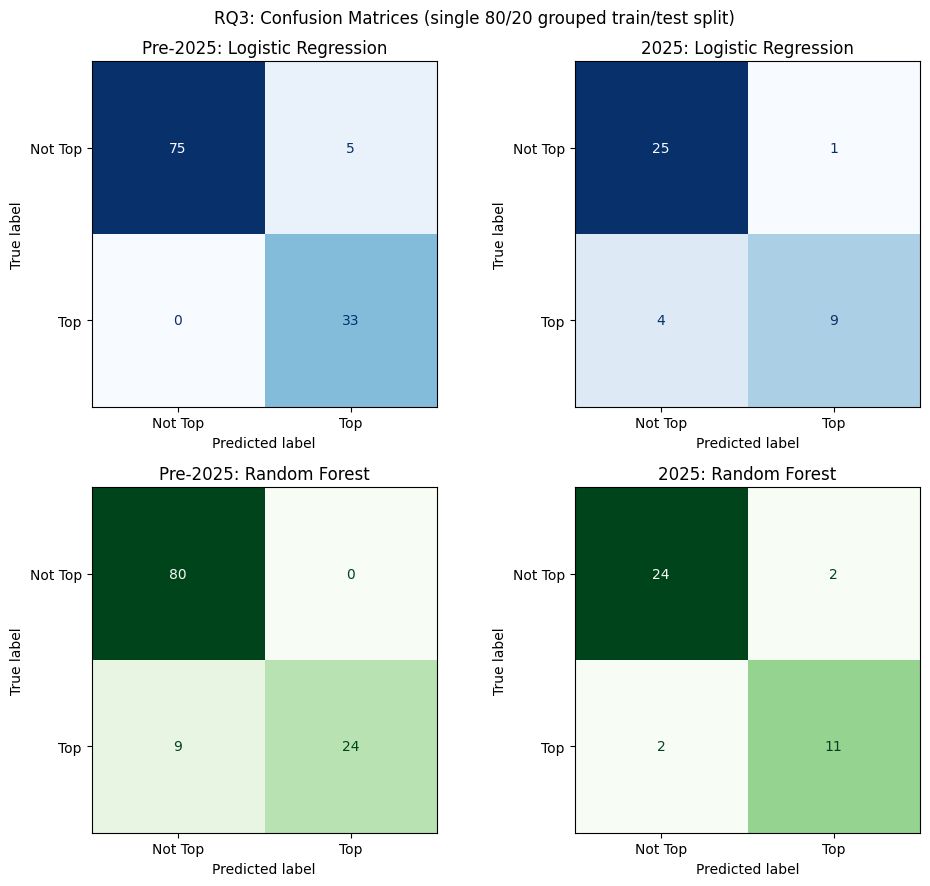

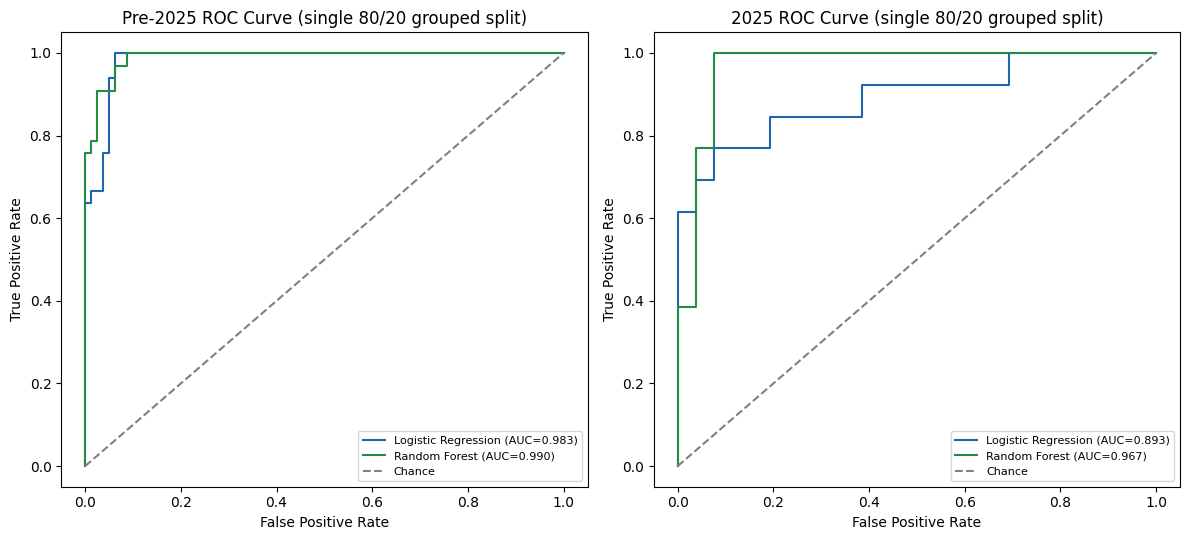

In [39]:
# ============================================================
# RQ3: Confusion matrices + ROC curves
#
# Uses a SINGLE grouped (by country) 80/20 train/test split per
# era -- purely for these visuals. The primary performance
# estimate remains the 5-fold grouped CV in rq3_model_training_cv.py;
# this single split is illustrative, not the headline result,
# since one split is more sensitive to which countries happen to
# land in the test set than the 5-fold average is.
# ============================================================
imputed = pd.read_csv(DATA_DIR + 'processed/analytic_dataset_imputed.csv')
tiers = pd.read_csv(DATA_DIR + 'processed/gari_readiness_long_with_tiers.csv')

PREDICTOR_COLS = [
    'GOV_WGI_CC_EST', 'GOV_WGI_PV_EST',
    'IT.NET.BBND.P2', 'IT.CEL.SETS.P2', 'NY.GDP.PCAP.PP.CD',
    'SE.TER.ENRR', 'IP.JRN.ARTC.SC', 'TX.VAL.TECH.MF.ZS',
]

df = imputed.merge(
    tiers[['iso3', 'year', 'tier']],
    left_on=['iso3', 'outcome_year'], right_on=['iso3', 'year'], how='left'
)
df['is_top_tier'] = (df['tier'] == 'Top').astype(int)

fig_cm, axes_cm = plt.subplots(2, 2, figsize=(10, 9))
fig_roc, axes_roc = plt.subplots(1, 2, figsize=(12, 5.5))

split_results = []

for i, (era, era_label) in enumerate([(0, 'Pre-2025'), (1, '2025')]):
    era_df = df[df['era'] == era].reset_index(drop=True)
    X = era_df[PREDICTOR_COLS].values
    y = era_df['is_top_tier'].values
    groups = era_df['iso3'].values

    gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
    train_idx, test_idx = next(gss.split(X, y, groups))

    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]

    n_train_countries = len(set(groups[train_idx]))
    n_test_countries = len(set(groups[test_idx]))
    overlap = set(groups[train_idx]) & set(groups[test_idx])
    print(f"{era_label}: train={len(X_train)} rows/{n_train_countries} countries, "
          f"test={len(X_test)} rows/{n_test_countries} countries, "
          f"country overlap between train/test: {len(overlap)} (should be 0)")

    scaler = StandardScaler().fit(X_train)
    X_train_s, X_test_s = scaler.transform(X_train), scaler.transform(X_test)

    log_model = LogisticRegression(max_iter=1000).fit(X_train_s, y_train)
    rf_model = RandomForestClassifier(n_estimators=300, random_state=42).fit(X_train, y_train)

    log_pred = log_model.predict(X_test_s)
    log_proba = log_model.predict_proba(X_test_s)[:, 1]
    rf_pred = rf_model.predict(X_test)
    rf_proba = rf_model.predict_proba(X_test)[:, 1]

    # --- Confusion matrices (Logistic top row, RF bottom row for this era's column) ---
    cm_log = confusion_matrix(y_test, log_pred)
    cm_rf = confusion_matrix(y_test, rf_pred)

    ConfusionMatrixDisplay(cm_log, display_labels=['Not Top', 'Top']).plot(
        ax=axes_cm[0, i], colorbar=False, cmap='Blues')
    axes_cm[0, i].set_title(f'{era_label}: Logistic Regression')

    ConfusionMatrixDisplay(cm_rf, display_labels=['Not Top', 'Top']).plot(
        ax=axes_cm[1, i], colorbar=False, cmap='Greens')
    axes_cm[1, i].set_title(f'{era_label}: Random Forest')

    # --- ROC curves (both models overlaid per era) ---
    fpr_log, tpr_log, _ = roc_curve(y_test, log_proba)
    fpr_rf, tpr_rf, _ = roc_curve(y_test, rf_proba)
    auc_log = roc_auc_score(y_test, log_proba)
    auc_rf = roc_auc_score(y_test, rf_proba)

    axes_roc[i].plot(fpr_log, tpr_log, label=f'Logistic Regression (AUC={auc_log:.3f})', color='#2166ac')
    axes_roc[i].plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC={auc_rf:.3f})', color='#238b45')
    axes_roc[i].plot([0, 1], [0, 1], linestyle='--', color='gray', label='Chance')
    axes_roc[i].set_xlabel('False Positive Rate')
    axes_roc[i].set_ylabel('True Positive Rate')
    axes_roc[i].set_title(f'{era_label} ROC Curve (single 80/20 grouped split)')
    axes_roc[i].legend(fontsize=8)

    split_results.append({
        'era': era_label, 'n_train': len(X_train), 'n_test': len(X_test),
        'n_train_countries': n_train_countries, 'n_test_countries': n_test_countries,
        'country_overlap': len(overlap),
        'log_auc': auc_log, 'rf_auc': auc_rf,
    })

fig_cm.suptitle('RQ3: Confusion Matrices (single 80/20 grouped train/test split)')
fig_cm.tight_layout()
fig_cm.savefig(DATA_DIR + 'processed/plot_rq3_confusion_matrices.png', dpi=150)

fig_roc.tight_layout()
fig_roc.show()
fig_roc.savefig(DATA_DIR + 'processed/plot_rq3_roc_curves.png', dpi=150)

print("\nSaved plot_rq3_confusion_matrices.png, plot_rq3_roc_curves.png")

pd.DataFrame(split_results).to_csv(DATA_DIR + 'processed/rq3_single_split_summary.csv', index=False)
print("Saved rq3_single_split_summary.csv")
print(pd.DataFrame(split_results).to_string(index=False))

####Linear Regression Visuals

Pre-2025: n_test=113
  Linear Regression: RMSE=7.55, R2=0.762
  Random Forest:     RMSE=4.57, R2=0.913
2025: n_test=39
  Linear Regression: RMSE=11.09, R2=0.631
  Random Forest:     RMSE=6.11, R2=0.888

Saved plot_rq3_predicted_vs_actual.png, plot_rq3_residuals.png
Saved rq3_regression_single_split_summary.csv


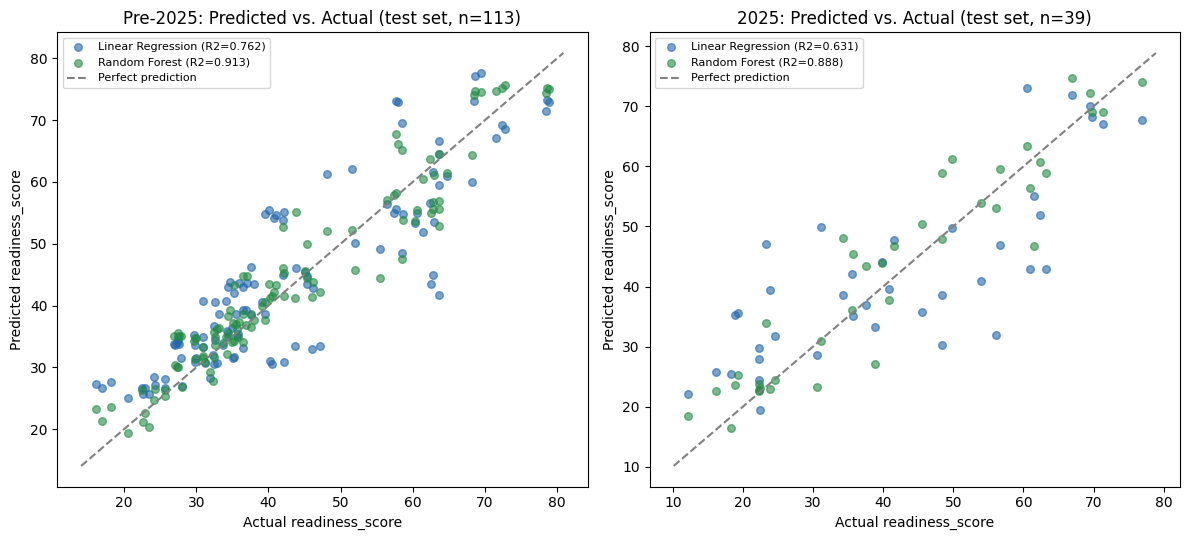

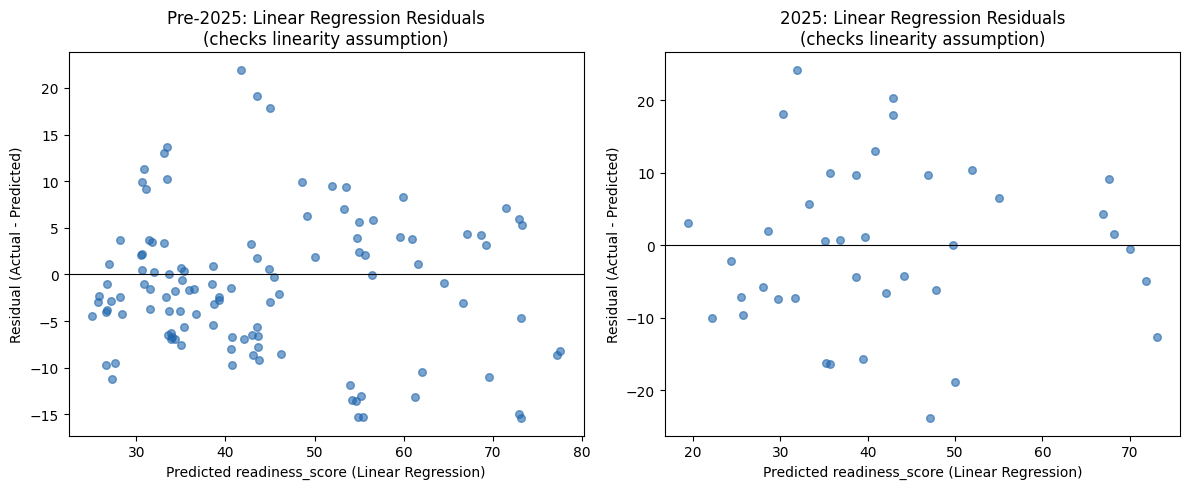

In [40]:
# ============================================================
# RQ3: Regression task visuals -- Linear Regression vs.
#      Random Forest Regressor
#
# Same single grouped 80/20 split logic as the classification
# visuals (rq3_confusion_matrix_roc.py), applied to the
# continuous readiness_score target instead.
#
# Includes a residual plot for Linear Regression specifically --
# this directly addresses the "linearity not yet tested" item
# flagged as pending in the Modelling section.
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import GroupShuffleSplit
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score

imputed = pd.read_csv(DATA_DIR + 'processed/analytic_dataset_imputed.csv')

PREDICTOR_COLS = [
    'GOV_WGI_CC_EST', 'GOV_WGI_PV_EST',
    'IT.NET.BBND.P2', 'IT.CEL.SETS.P2', 'NY.GDP.PCAP.PP.CD',
    'SE.TER.ENRR', 'IP.JRN.ARTC.SC', 'TX.VAL.TECH.MF.ZS',
]

fig_pred, axes_pred = plt.subplots(1, 2, figsize=(12, 5.5))
fig_resid, axes_resid = plt.subplots(1, 2, figsize=(12, 5))

split_results = []

for i, (era, era_label) in enumerate([(0, 'Pre-2025'), (1, '2025')]):
    era_df = imputed[imputed['era'] == era].reset_index(drop=True)
    X = era_df[PREDICTOR_COLS].values
    y = era_df['readiness_score'].values
    groups = era_df['iso3'].values

    # Same split strategy (grouped, 80/20, same random_state) as the
    # classification visuals -- not literally the same row indices
    # (different target array shape isn't the issue, GroupShuffleSplit
    # only depends on groups/X shape, so this reproduces the identical
    # train/test country split as rq3_confusion_matrix_roc.py)
    gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
    train_idx, test_idx = next(gss.split(X, y, groups))

    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]

    scaler = StandardScaler().fit(X_train)
    X_train_s, X_test_s = scaler.transform(X_train), scaler.transform(X_test)

    lr = LinearRegression().fit(X_train_s, y_train)
    rf = RandomForestRegressor(n_estimators=300, random_state=42).fit(X_train, y_train)

    lr_pred = lr.predict(X_test_s)
    rf_pred = rf.predict(X_test)

    lr_rmse = np.sqrt(mean_squared_error(y_test, lr_pred))
    rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
    lr_r2 = r2_score(y_test, lr_pred)
    rf_r2 = r2_score(y_test, rf_pred)

    print(f"{era_label}: n_test={len(y_test)}")
    print(f"  Linear Regression: RMSE={lr_rmse:.2f}, R2={lr_r2:.3f}")
    print(f"  Random Forest:     RMSE={rf_rmse:.2f}, R2={rf_r2:.3f}")

    # --- Predicted vs Actual scatter ---
    ax = axes_pred[i]
    ax.scatter(y_test, lr_pred, alpha=0.6, label=f'Linear Regression (R2={lr_r2:.3f})', color='#2166ac', s=30)
    ax.scatter(y_test, rf_pred, alpha=0.6, label=f'Random Forest (R2={rf_r2:.3f})', color='#238b45', s=30)
    lims = [min(y_test.min(), lr_pred.min(), rf_pred.min()) - 2,
            max(y_test.max(), lr_pred.max(), rf_pred.max()) + 2]
    ax.plot(lims, lims, linestyle='--', color='gray', label='Perfect prediction')
    ax.set_xlabel('Actual readiness_score')
    ax.set_ylabel('Predicted readiness_score')
    ax.set_title(f'{era_label}: Predicted vs. Actual (test set, n={len(y_test)})')
    ax.legend(fontsize=8)

    # --- Residual plot (Linear Regression only -- linearity check) ---
    residuals = y_test - lr_pred
    ax2 = axes_resid[i]
    ax2.scatter(lr_pred, residuals, alpha=0.6, color='#2166ac', s=30)
    ax2.axhline(0, color='black', linewidth=0.8)
    ax2.set_xlabel('Predicted readiness_score (Linear Regression)')
    ax2.set_ylabel('Residual (Actual - Predicted)')
    ax2.set_title(f'{era_label}: Linear Regression Residuals\n(checks linearity assumption)')

    split_results.append({
        'era': era_label, 'n_test': len(y_test),
        'lr_rmse': lr_rmse, 'rf_rmse': rf_rmse,
        'lr_r2': lr_r2, 'rf_r2': rf_r2,
    })

fig_pred.tight_layout()
fig_pred.show()
fig_pred.savefig(DATA_DIR + 'processed/plot_rq3_predicted_vs_actual.png', dpi=150)

fig_resid.tight_layout()
fig_resid.show()
fig_resid.savefig(DATA_DIR + 'processed/plot_rq3_residuals.png', dpi=150)

print("\nSaved plot_rq3_predicted_vs_actual.png, plot_rq3_residuals.png")

pd.DataFrame(split_results).to_csv(DATA_DIR + 'processed/rq3_regression_single_split_summary.csv', index=False)
print("Saved rq3_regression_single_split_summary.csv")

####Hypothesis Testing

In [41]:
# ============================================================
# RQ3 formal hypothesis tests
#
# H0_3a: models do not predict readiness more accurately than
#        chance -- tested via permutation test (grouped, to
#        preserve the leakage-prevention design)
# H0_3b: no meaningful difference in predictive performance
#        between pre-2025 and 2025 -- tested via Welch's t-test
#        comparing the 5 fold-level CV scores per era
#
# NOTE: this script re-runs the CV process (same design as
# rq3_model_training_cv.py) but additionally stores per-fold
# scores (needed for the H0_3b t-test) and runs permutation
# tests (needed for H0_3a). Random Forest uses fewer trees
# (100 instead of 300) ONLY inside the permutation test loop,
# for computational feasibility -- the primary CV results in
# rq3_model_training_cv.py (300 trees) are unaffected.
# ============================================================
import pandas as pd
import numpy as np
from sklearn.model_selection import GroupKFold, permutation_test_score
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from scipy import stats

imputed = pd.read_csv(DATA_DIR + 'processed/analytic_dataset_imputed.csv')
tiers = pd.read_csv(DATA_DIR + 'processed/gari_readiness_long_with_tiers.csv')

PREDICTOR_COLS = [
    'GOV_WGI_CC_EST', 'GOV_WGI_PV_EST',
    'IT.NET.BBND.P2', 'IT.CEL.SETS.P2', 'NY.GDP.PCAP.PP.CD',
    'SE.TER.ENRR', 'IP.JRN.ARTC.SC', 'TX.VAL.TECH.MF.ZS',
]

df = imputed.merge(
    tiers[['iso3', 'year', 'tier']],
    left_on=['iso3', 'outcome_year'], right_on=['iso3', 'year'], how='left'
)
df['is_top_tier'] = (df['tier'] == 'Top').astype(int)

N_PERMUTATIONS = 100  # empirical p-value resolution is 1/(N_PERMUTATIONS+1) = ~0.0099
RANDOM_STATE = 42

fold_scores = []       # for H0_3b (per-fold scores by era)
permutation_results = []  # for H0_3a

for era, era_label in [(0, 'Pre-2025'), (1, '2025')]:
    era_df = df[df['era'] == era].reset_index(drop=True)
    X = era_df[PREDICTOR_COLS].values
    y_reg = era_df['readiness_score'].values
    y_clf = era_df['is_top_tier'].values
    groups = era_df['iso3'].values
    gkf = GroupKFold(n_splits=5)

    print(f"\n{'='*70}\n{era_label}\n{'='*70}")

    # ------------------------------------------------------------
    # H0_3a: permutation tests (grouped CV under the hood)
    # ------------------------------------------------------------
    # Regression: Linear Regression (with scaling) and Random Forest
    lr_pipe = Pipeline([('scale', StandardScaler()), ('model', LinearRegression())])
    score, perm_scores, pval = permutation_test_score(
        lr_pipe, X, y_reg, groups=groups, cv=gkf, scoring='r2',
        n_permutations=N_PERMUTATIONS, random_state=RANDOM_STATE, n_jobs=-1
    )
    print(f"[H0_3a] Linear Regression (R2): observed={score:.3f}, "
          f"null mean={perm_scores.mean():.3f}, p={pval:.4f}")
    permutation_results.append({'era': era_label, 'task': 'regression', 'model': 'Linear Regression',
                                 'metric': 'R2', 'observed': score, 'null_mean': perm_scores.mean(),
                                 'p_value': pval})

    rf_reg = RandomForestRegressor(n_estimators=100, random_state=RANDOM_STATE)
    score, perm_scores, pval = permutation_test_score(
        rf_reg, X, y_reg, groups=groups, cv=gkf, scoring='r2',
        n_permutations=N_PERMUTATIONS, random_state=RANDOM_STATE, n_jobs=-1
    )
    print(f"[H0_3a] Random Forest (R2):     observed={score:.3f}, "
          f"null mean={perm_scores.mean():.3f}, p={pval:.4f}")
    permutation_results.append({'era': era_label, 'task': 'regression', 'model': 'Random Forest',
                                 'metric': 'R2', 'observed': score, 'null_mean': perm_scores.mean(),
                                 'p_value': pval})

    # Classification: Logistic Regression and Random Forest
    log_pipe = Pipeline([('scale', StandardScaler()), ('model', LogisticRegression(max_iter=1000))])
    score, perm_scores, pval = permutation_test_score(
        log_pipe, X, y_clf, groups=groups, cv=gkf, scoring='accuracy',
        n_permutations=N_PERMUTATIONS, random_state=RANDOM_STATE, n_jobs=-1
    )
    print(f"[H0_3a] Logistic Regression (Acc): observed={score:.3f}, "
          f"null mean={perm_scores.mean():.3f}, p={pval:.4f}")
    permutation_results.append({'era': era_label, 'task': 'classification', 'model': 'Logistic Regression',
                                 'metric': 'Accuracy', 'observed': score, 'null_mean': perm_scores.mean(),
                                 'p_value': pval})

    rf_clf = RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE)
    score, perm_scores, pval = permutation_test_score(
        rf_clf, X, y_clf, groups=groups, cv=gkf, scoring='accuracy',
        n_permutations=N_PERMUTATIONS, random_state=RANDOM_STATE, n_jobs=-1
    )
    print(f"[H0_3a] Random Forest (Acc):       observed={score:.3f}, "
          f"null mean={perm_scores.mean():.3f}, p={pval:.4f}")
    permutation_results.append({'era': era_label, 'task': 'classification', 'model': 'Random Forest',
                                 'metric': 'Accuracy', 'observed': score, 'null_mean': perm_scores.mean(),
                                 'p_value': pval})

    # ------------------------------------------------------------
    # Per-fold scores, needed for H0_3b (era comparison)
    # ------------------------------------------------------------
    lr_r2_folds, rf_r2_folds = [], []
    log_acc_folds, rfc_acc_folds = [], []

    for train_idx, test_idx in gkf.split(X, y_reg, groups):
        X_train, X_test = X[train_idx], X[test_idx]
        y_train, y_test = y_reg[train_idx], y_reg[test_idx]
        scaler = StandardScaler().fit(X_train)
        lr = LinearRegression().fit(scaler.transform(X_train), y_train)
        lr_r2_folds.append(lr.score(scaler.transform(X_test), y_test))
        rf = RandomForestRegressor(n_estimators=300, random_state=RANDOM_STATE).fit(X_train, y_train)
        rf_r2_folds.append(rf.score(X_test, y_test))

    for train_idx, test_idx in gkf.split(X, y_clf, groups):
        X_train, X_test = X[train_idx], X[test_idx]
        y_train, y_test = y_clf[train_idx], y_clf[test_idx]
        scaler = StandardScaler().fit(X_train)
        log_model = LogisticRegression(max_iter=1000).fit(scaler.transform(X_train), y_train)
        log_acc_folds.append(log_model.score(scaler.transform(X_test), y_test))
        rfc = RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE).fit(X_train, y_train)
        rfc_acc_folds.append(rfc.score(X_test, y_test))

    fold_scores.append({'era': era_label, 'model': 'Linear Regression', 'metric': 'R2', 'folds': lr_r2_folds})
    fold_scores.append({'era': era_label, 'model': 'Random Forest (reg)', 'metric': 'R2', 'folds': rf_r2_folds})
    fold_scores.append({'era': era_label, 'model': 'Logistic Regression', 'metric': 'Accuracy', 'folds': log_acc_folds})
    fold_scores.append({'era': era_label, 'model': 'Random Forest (clf)', 'metric': 'Accuracy', 'folds': rfc_acc_folds})

# ------------------------------------------------------------
# H0_3b: Welch's t-test, era 0 folds vs. era 1 folds, per model
# ------------------------------------------------------------
print(f"\n{'='*70}\nH0_3b: ERA COMPARISON (Welch's t-test on 5-fold CV scores)\n{'='*70}")
print("NOTE: n=5 per era is a small sample for this test -- treat as indicative, not definitive.\n")

h03b_results = []
fold_df = pd.DataFrame(fold_scores)
for model in fold_df['model'].unique():
    era0_folds = fold_df[(fold_df['model'] == model) & (fold_df['era'] == 'Pre-2025')]['folds'].iloc[0]
    era1_folds = fold_df[(fold_df['model'] == model) & (fold_df['era'] == '2025')]['folds'].iloc[0]
    t_stat, p_val = stats.ttest_ind(era0_folds, era1_folds, equal_var=False)
    print(f"{model}: Pre-2025 mean={np.mean(era0_folds):.3f}, 2025 mean={np.mean(era1_folds):.3f}, "
          f"t={t_stat:.3f}, p={p_val:.4f}")
    h03b_results.append({'model': model, 'era0_mean': np.mean(era0_folds), 'era1_mean': np.mean(era1_folds),
                          't_stat': t_stat, 'p_value': p_val})

# ------------------------------------------------------------
# Save
# ------------------------------------------------------------
pd.DataFrame(permutation_results).to_csv(DATA_DIR + 'processed/rq3_h03a_permutation_tests.csv', index=False)
pd.DataFrame(h03b_results).to_csv(DATA_DIR + 'processed/rq3_h03b_era_comparison_tests.csv', index=False)
print("\nSaved rq3_h03a_permutation_tests.csv, rq3_h03b_era_comparison_tests.csv")


Pre-2025
[H0_3a] Linear Regression (R2): observed=0.756, null mean=0.750, p=0.0099
[H0_3a] Random Forest (R2):     observed=0.865, null mean=0.859, p=0.0297
[H0_3a] Logistic Regression (Acc): observed=0.871, null mean=0.872, p=0.6634
[H0_3a] Random Forest (Acc):       observed=0.893, null mean=0.897, p=0.8020

2025
[H0_3a] Linear Regression (R2): observed=0.554, null mean=0.554, p=1.0000
[H0_3a] Random Forest (R2):     observed=0.869, null mean=0.869, p=1.0000
[H0_3a] Logistic Regression (Acc): observed=0.861, null mean=0.861, p=1.0000
[H0_3a] Random Forest (Acc):       observed=0.918, null mean=0.918, p=1.0000

H0_3b: ERA COMPARISON (Welch's t-test on 5-fold CV scores)
NOTE: n=5 per era is a small sample for this test -- treat as indicative, not definitive.

Linear Regression: Pre-2025 mean=0.756, 2025 mean=0.554, t=2.533, p=0.0481
Random Forest (reg): Pre-2025 mean=0.867, 2025 mean=0.869, t=-0.064, p=0.9505
Logistic Regression: Pre-2025 mean=0.871, 2025 mean=0.861, t=0.311, p=0.7644

##RQ4

In [44]:
from sklearn.inspection import permutation_importance

In [45]:
# ============================================================
# RQ4: Feature importance, methods 1-3 of 4
#   1. Standardized logistic regression coefficients / odds ratios
#      (full era dataset, cluster-robust SE by country -- explanatory,
#      same convention as RQ2's regression, not a predictive-accuracy task)
#   2. Permutation importance for Random Forest (regressor + classifier)
#      (computed on the SAME held-out test split as RQ3's confusion
#      matrix script, to avoid overfitting bias from training-set importance)
#   3. Decision-tree split (impurity-based) importance for Random Forest
#      (a property of the fitted model itself, from the same train split)
#
# Run separately per era, per the agreed design.
# SHAP (method 4) is a separate follow-up script.
# ============================================================
imputed = pd.read_csv(DATA_DIR + 'processed/analytic_dataset_imputed.csv')
tiers = pd.read_csv(DATA_DIR + 'processed/gari_readiness_long_with_tiers.csv')

PREDICTOR_COLS = [
    'GOV_WGI_CC_EST', 'GOV_WGI_PV_EST',
    'IT.NET.BBND.P2', 'IT.CEL.SETS.P2', 'NY.GDP.PCAP.PP.CD',
    'SE.TER.ENRR', 'IP.JRN.ARTC.SC', 'TX.VAL.TECH.MF.ZS',
]
LABELS = {
    'GOV_WGI_CC_EST': 'Control of Corruption', 'GOV_WGI_PV_EST': 'Political Stability',
    'IT.NET.BBND.P2': 'Fixed Broadband', 'IT.CEL.SETS.P2': 'Mobile Subscriptions',
    'NY.GDP.PCAP.PP.CD': 'GDP per capita', 'SE.TER.ENRR': 'Tertiary Enrolment',
    'IP.JRN.ARTC.SC': 'Journal Articles', 'TX.VAL.TECH.MF.ZS': 'High-Tech Exports',
}

df = imputed.merge(
    tiers[['iso3', 'year', 'tier']],
    left_on=['iso3', 'outcome_year'], right_on=['iso3', 'year'], how='left'
)
df['is_top_tier'] = (df['tier'] == 'Top').astype(int)

# ------------------------------------------------------------
# Log-transform Journal Articles before this analysis.
#
# WHY: the raw predictor produced clearly unstable estimates in an
# initial run -- odds ratios of ~1,300 (pre-2025) and ~17,600 (2025)
# alongside NON-significant p-values (p=0.21, p=0.20). That specific
# combination (huge point estimate + non-significant p-value) is the
# signature of quasi-separation: because Journal Articles is extremely
# right-skewed (dominated by China and the US), very few countries
# have large values, and those happen to align closely with "Top tier"
# status -- the model can technically fit something, but the resulting
# coefficient is numerically unstable, not a genuine, trustworthy effect.
#
# This is ALSO a practical-plausibility problem, independent of the
# statistics: even a strong estimated association would not credibly
# mean "publish more academic papers" is a primary AI-readiness policy
# lever, compared to governance quality, connectivity, or GDP. A
# log-transform (log1p, safe for any zero counts) compresses the
# extreme right tail and should produce a more stable, more plausible
# estimate if the underlying relationship is real.
#
# SCOPE NOTE: this transform is applied HERE (RQ4) only. RQ2 and RQ3's
# already-reported results still use the raw Journal Articles values --
# this is a known, explicitly-flagged inconsistency for the final
# report to resolve (either accept as a documented refinement
# discovered during RQ4's deeper diagnostics, or re-run RQ2/RQ3 with
# the log version later).
# ------------------------------------------------------------
df['IP.JRN.ARTC.SC_log'] = np.log1p(df['IP.JRN.ARTC.SC'])
PREDICTOR_COLS = [c if c != 'IP.JRN.ARTC.SC' else 'IP.JRN.ARTC.SC_log' for c in PREDICTOR_COLS]
LABELS['IP.JRN.ARTC.SC_log'] = 'Journal Articles (log)'

all_odds_ratios = []
all_perm_importance = []
all_split_importance = []

for era, era_label in [(0, 'Pre-2025'), (1, '2025')]:
    era_df = df[df['era'] == era].reset_index(drop=True)
    print(f"\n{'='*70}\n{era_label} (n={len(era_df)})\n{'='*70}")

    # ------------------------------------------------------------
    # Method 1: Odds ratios (statsmodels Logit, full era data,
    # cluster-robust SE, standardized predictors for comparability)
    # ------------------------------------------------------------
    X_full = era_df[PREDICTOR_COLS].copy()
    X_full_std = (X_full - X_full.mean()) / X_full.std()
    X_full_std = sm.add_constant(X_full_std)
    y_full = era_df['is_top_tier']

    logit_robust = sm.Logit(y_full, X_full_std).fit(
        disp=0, cov_type='cluster', cov_kwds={'groups': era_df['iso3']}
    )

    print("\n--- Odds Ratios (Logistic Regression, standardized) ---")
    for col in PREDICTOR_COLS:
        coef = logit_robust.params[col]
        pval = logit_robust.pvalues[col]
        odds_ratio = np.exp(coef)
        print(f"{LABELS[col]:30s} coef={coef:+.3f}  OR={odds_ratio:.3f}  p={pval:.4f}")
        all_odds_ratios.append({'era': era_label, 'predictor': LABELS[col],
                                 'coef': coef, 'odds_ratio': odds_ratio, 'p_value': pval})

    # ------------------------------------------------------------
    # Held-out split (SAME design as rq3_confusion_matrix_roc.py --
    # grouped by country, 80/20, random_state=42) for methods 2-3
    # ------------------------------------------------------------
    X = era_df[PREDICTOR_COLS].values
    y_reg = era_df['readiness_score'].values
    y_clf = era_df['is_top_tier'].values
    groups = era_df['iso3'].values

    gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
    train_idx, test_idx = next(gss.split(X, y_reg, groups))
    X_train, X_test = X[train_idx], X[test_idx]
    y_reg_train, y_reg_test = y_reg[train_idx], y_reg[test_idx]
    y_clf_train, y_clf_test = y_clf[train_idx], y_clf[test_idx]

    rf_reg = RandomForestRegressor(n_estimators=300, random_state=42).fit(X_train, y_reg_train)
    rf_clf = RandomForestClassifier(n_estimators=300, random_state=42).fit(X_train, y_clf_train)

    # ------------------------------------------------------------
    # Method 2: Permutation importance (on the HELD-OUT test set)
    # ------------------------------------------------------------
    perm_reg = permutation_importance(rf_reg, X_test, y_reg_test, n_repeats=30,
                                        random_state=42, scoring='r2')
    perm_clf = permutation_importance(rf_clf, X_test, y_clf_test, n_repeats=30,
                                        random_state=42, scoring='accuracy')

    print("\n--- Permutation Importance (Random Forest, held-out test set) ---")
    print(f"{'Predictor':30s} {'Regression (R2 drop)':>22s} {'Classification (Acc drop)':>26s}")
    for i, col in enumerate(PREDICTOR_COLS):
        print(f"{LABELS[col]:30s} {perm_reg.importances_mean[i]:>22.4f} {perm_clf.importances_mean[i]:>26.4f}")
        all_perm_importance.append({
            'era': era_label, 'predictor': LABELS[col],
            'perm_importance_regression_r2': perm_reg.importances_mean[i],
            'perm_importance_regression_r2_std': perm_reg.importances_std[i],
            'perm_importance_classification_acc': perm_clf.importances_mean[i],
            'perm_importance_classification_acc_std': perm_clf.importances_std[i],
        })

    # ------------------------------------------------------------
    # Method 3: Decision-tree split (impurity-based) importance
    # ------------------------------------------------------------
    print("\n--- Split (Impurity-Based) Importance (Random Forest) ---")
    print(f"{'Predictor':30s} {'Regression':>12s} {'Classification':>16s}")
    for i, col in enumerate(PREDICTOR_COLS):
        print(f"{LABELS[col]:30s} {rf_reg.feature_importances_[i]:>12.4f} {rf_clf.feature_importances_[i]:>16.4f}")
        all_split_importance.append({
            'era': era_label, 'predictor': LABELS[col],
            'split_importance_regression': rf_reg.feature_importances_[i],
            'split_importance_classification': rf_clf.feature_importances_[i],
        })

# ------------------------------------------------------------
# Save
# ------------------------------------------------------------
pd.DataFrame(all_odds_ratios).to_csv(DATA_DIR + 'processed/rq4_odds_ratios.csv', index=False)
pd.DataFrame(all_perm_importance).to_csv(DATA_DIR + 'processed/rq4_permutation_importance.csv', index=False)
pd.DataFrame(all_split_importance).to_csv(DATA_DIR + 'processed/rq4_split_importance.csv', index=False)
print("\n\nSaved: rq4_odds_ratios.csv, rq4_permutation_importance.csv, rq4_split_importance.csv")



Pre-2025 (n=559)

--- Odds Ratios (Logistic Regression, standardized) ---
Control of Corruption          coef=+1.771  OR=5.879  p=0.0187
Political Stability            coef=+0.296  OR=1.345  p=0.6728
Fixed Broadband                coef=+0.470  OR=1.600  p=0.2849
Mobile Subscriptions           coef=+0.240  OR=1.272  p=0.4270
GDP per capita                 coef=+0.464  OR=1.590  p=0.3087
Tertiary Enrolment             coef=+0.746  OR=2.109  p=0.1101
Journal Articles (log)         coef=+3.658  OR=38.802  p=0.0000
High-Tech Exports              coef=+0.489  OR=1.630  p=0.0439

--- Permutation Importance (Random Forest, held-out test set) ---
Predictor                        Regression (R2 drop)  Classification (Acc drop)
Control of Corruption                          0.0974                     0.0342
Political Stability                            0.0056                     0.0094
Fixed Broadband                                0.0134                     0.0248
Mobile Subscriptions         

In [47]:
import shap


Pre-2025: SHAP Global Importance
Journal Articles (log)         mean|SHAP|=0.1368
Fixed Broadband                mean|SHAP|=0.0859
GDP per capita                 mean|SHAP|=0.0782
Control of Corruption          mean|SHAP|=0.0527
Tertiary Enrolment             mean|SHAP|=0.0513
High-Tech Exports              mean|SHAP|=0.0307
Mobile Subscriptions           mean|SHAP|=0.0251
Political Stability            mean|SHAP|=0.0095

Pre-2025: Approximate thresholds (SHAP sign-crossing point)
  Journal Articles (log) [log scale] approx. threshold ~ 7.60
  Fixed Broadband                approx. threshold ~ 19.28
  GDP per capita                 approx. threshold ~ 30834.18
  Control of Corruption          approx. threshold ~ 0.14

2025: SHAP Global Importance
Journal Articles (log)         mean|SHAP|=0.1804
Tertiary Enrolment             mean|SHAP|=0.0722
GDP per capita                 mean|SHAP|=0.0714
Fixed Broadband                mean|SHAP|=0.0411
Control of Corruption          mean|SHAP|=0.03

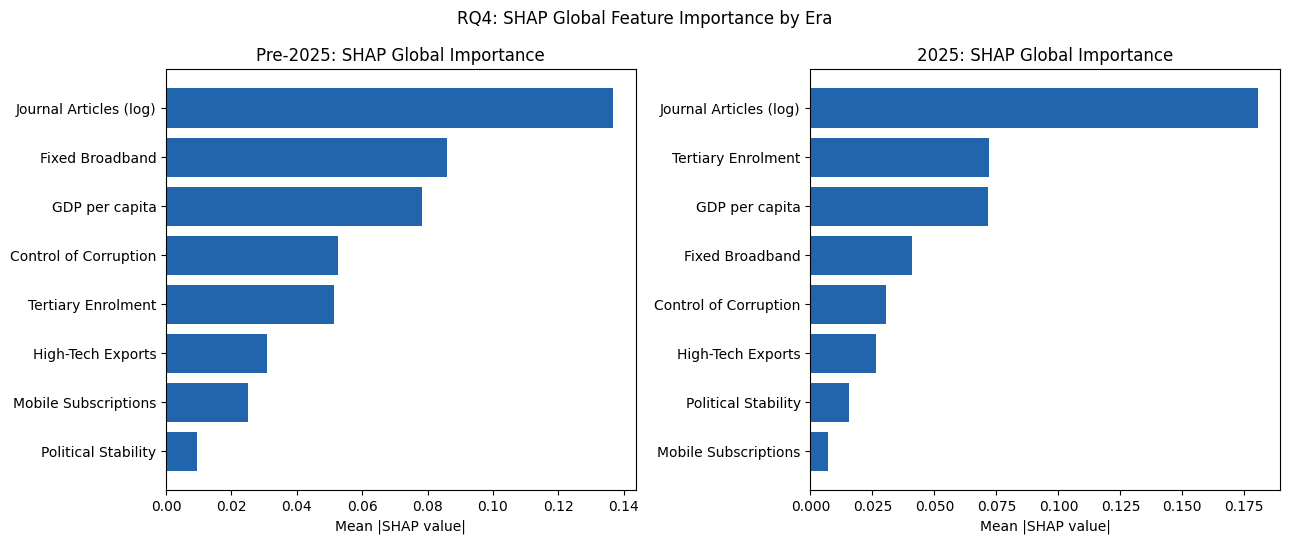

In [48]:
# ============================================================
# RQ4: SHAP analysis (method 4 of 4)
#   - Global importance (mean |SHAP value| per predictor)
#   - Dependence plots for the top predictors (feature value vs.
#     SHAP contribution to "Top tier" probability)
#   - Automatic threshold extraction: the approximate point where
#     each dependence curve crosses from negative to positive
#     contribution -- directly answers RQ4's threshold question
#
# Model fit on the SAME train split as rq4_feature_importance_part1.py
# (no leakage), but SHAP values are computed across the FULL era
# dataset -- this is an explanatory task (same convention as the
# odds ratios / RQ2 regression), not a predictive-accuracy
# evaluation, so using more data gives smoother, more reliable
# dependence curves than the ~20% test set alone would.
#
# Journal Articles uses the SAME log1p transform as Part 1, for
# the same numerical-stability and plausibility reasons.
# ============================================================

imputed = pd.read_csv(DATA_DIR + 'processed/analytic_dataset_imputed.csv')
tiers = pd.read_csv(DATA_DIR + 'processed/gari_readiness_long_with_tiers.csv')

PREDICTOR_COLS = [
    'GOV_WGI_CC_EST', 'GOV_WGI_PV_EST',
    'IT.NET.BBND.P2', 'IT.CEL.SETS.P2', 'NY.GDP.PCAP.PP.CD',
    'SE.TER.ENRR', 'IP.JRN.ARTC.SC', 'TX.VAL.TECH.MF.ZS',
]
LABELS = {
    'GOV_WGI_CC_EST': 'Control of Corruption', 'GOV_WGI_PV_EST': 'Political Stability',
    'IT.NET.BBND.P2': 'Fixed Broadband', 'IT.CEL.SETS.P2': 'Mobile Subscriptions',
    'NY.GDP.PCAP.PP.CD': 'GDP per capita', 'SE.TER.ENRR': 'Tertiary Enrolment',
    'IP.JRN.ARTC.SC': 'Journal Articles (log)', 'TX.VAL.TECH.MF.ZS': 'High-Tech Exports',
}

df = imputed.merge(
    tiers[['iso3', 'year', 'tier']],
    left_on=['iso3', 'outcome_year'], right_on=['iso3', 'year'], how='left'
)
df['is_top_tier'] = (df['tier'] == 'Top').astype(int)
df['IP.JRN.ARTC.SC'] = np.log1p(df['IP.JRN.ARTC.SC'])  # same transform as Part 1

fig_global, axes_global = plt.subplots(1, 2, figsize=(13, 5.5))
all_threshold_results = []
all_global_importance = []
era_shap_data = {}  # keep for dependence plots below

for i, (era, era_label) in enumerate([(0, 'Pre-2025'), (1, '2025')]):
    era_df = df[df['era'] == era].reset_index(drop=True)
    X = era_df[PREDICTOR_COLS]
    y = era_df['is_top_tier'].values
    groups = era_df['iso3'].values

    gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
    train_idx, test_idx = next(gss.split(X, y, groups))
    X_train, y_train = X.iloc[train_idx], y[train_idx]

    rf = RandomForestClassifier(n_estimators=300, random_state=42).fit(X_train, y_train)

    explainer = shap.TreeExplainer(rf)
    shap_exp = explainer(X)  # explain across the FULL era dataset
    shap_values = shap_exp.values[:, :, 1]  # class 1 = "Top tier"

    era_shap_data[era_label] = {'X': X, 'shap_values': shap_values}

    # --- Global importance: mean |SHAP value| ---
    mean_abs_shap = np.abs(shap_values).mean(axis=0)
    importance_order = np.argsort(mean_abs_shap)[::-1]

    print(f"\n{'='*70}\n{era_label}: SHAP Global Importance\n{'='*70}")
    for idx in importance_order:
        col = PREDICTOR_COLS[idx]
        print(f"{LABELS[col]:30s} mean|SHAP|={mean_abs_shap[idx]:.4f}")
        all_global_importance.append({'era': era_label, 'predictor': LABELS[col],
                                       'mean_abs_shap': mean_abs_shap[idx]})

    ax = axes_global[i]
    sorted_labels = [LABELS[PREDICTOR_COLS[idx]] for idx in importance_order]
    ax.barh(sorted_labels[::-1], mean_abs_shap[importance_order][::-1], color='#2166ac')
    ax.set_xlabel('Mean |SHAP value|')
    ax.set_title(f'{era_label}: SHAP Global Importance')

    # --- Threshold extraction for the top 4 predictors ---
    print(f"\n{era_label}: Approximate thresholds (SHAP sign-crossing point)")
    top4_idx = importance_order[:4]
    for idx in top4_idx:
        col = PREDICTOR_COLS[idx]
        feature_vals = X.iloc[:, idx].values
        shap_vals_this_feature = shap_values[:, idx]

        order = np.argsort(feature_vals)
        sorted_vals = feature_vals[order]
        sorted_shap = shap_vals_this_feature[order]

        # smooth with a rolling mean (window = 15% of n) before finding the
        # sign-crossing point, since raw SHAP values are noisy point-by-point
        window = max(5, int(len(sorted_shap) * 0.15))
        smoothed = pd.Series(sorted_shap).rolling(window, center=True, min_periods=1).mean().values

        # find the first crossing from negative to positive
        threshold_val, crossing_found = None, False
        for j in range(len(smoothed) - 1):
            if smoothed[j] < 0 <= smoothed[j + 1]:
                threshold_val = sorted_vals[j + 1]
                crossing_found = True
                break

        label = LABELS[col] + (" [log scale]" if col == 'IP.JRN.ARTC.SC' else "")
        if crossing_found:
            print(f"  {label:30s} approx. threshold ~ {threshold_val:.2f}")
        else:
            print(f"  {label:30s} no clear sign crossing (consistently {'positive' if smoothed.mean()>0 else 'negative'} contribution across the observed range)")

        all_threshold_results.append({
            'era': era_label, 'predictor': label,
            'threshold': threshold_val, 'crossing_found': crossing_found,
        })

fig_global.suptitle('RQ4: SHAP Global Feature Importance by Era')
fig_global.tight_layout()
fig_global.savefig(DATA_DIR + 'processed/plot_rq4_shap_global_importance.png', dpi=150)
print("\nSaved plot_rq4_shap_global_importance.png")

pd.DataFrame(all_global_importance).to_csv(DATA_DIR + 'processed/rq4_shap_global_importance.csv', index=False)
pd.DataFrame(all_threshold_results).to_csv(DATA_DIR + 'processed/rq4_shap_thresholds.csv', index=False)
print("Saved rq4_shap_global_importance.csv, rq4_shap_thresholds.csv")

# Save era_shap_data for the dependence-plot script to reuse without refitting
import pickle
with open('rq4_shap_data.pkl', 'wb') as f:
    pickle.dump({'era_shap_data': era_shap_data, 'PREDICTOR_COLS': PREDICTOR_COLS, 'LABELS': LABELS}, f)
print("Saved rq4_shap_data.pkl (for dependence plot script)")


In [49]:
import pickle

Saved plot_rq4_shap_dependence_pre2025.png
Saved plot_rq4_shap_dependence_2025.png


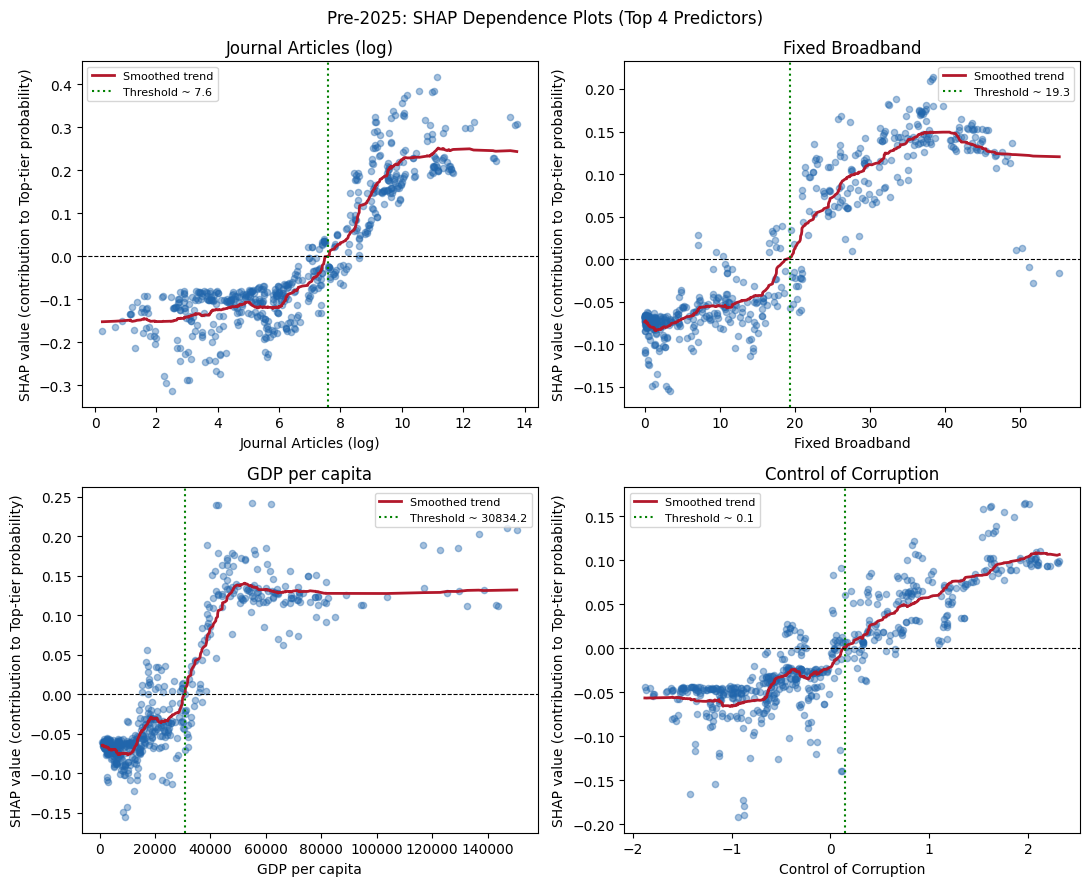

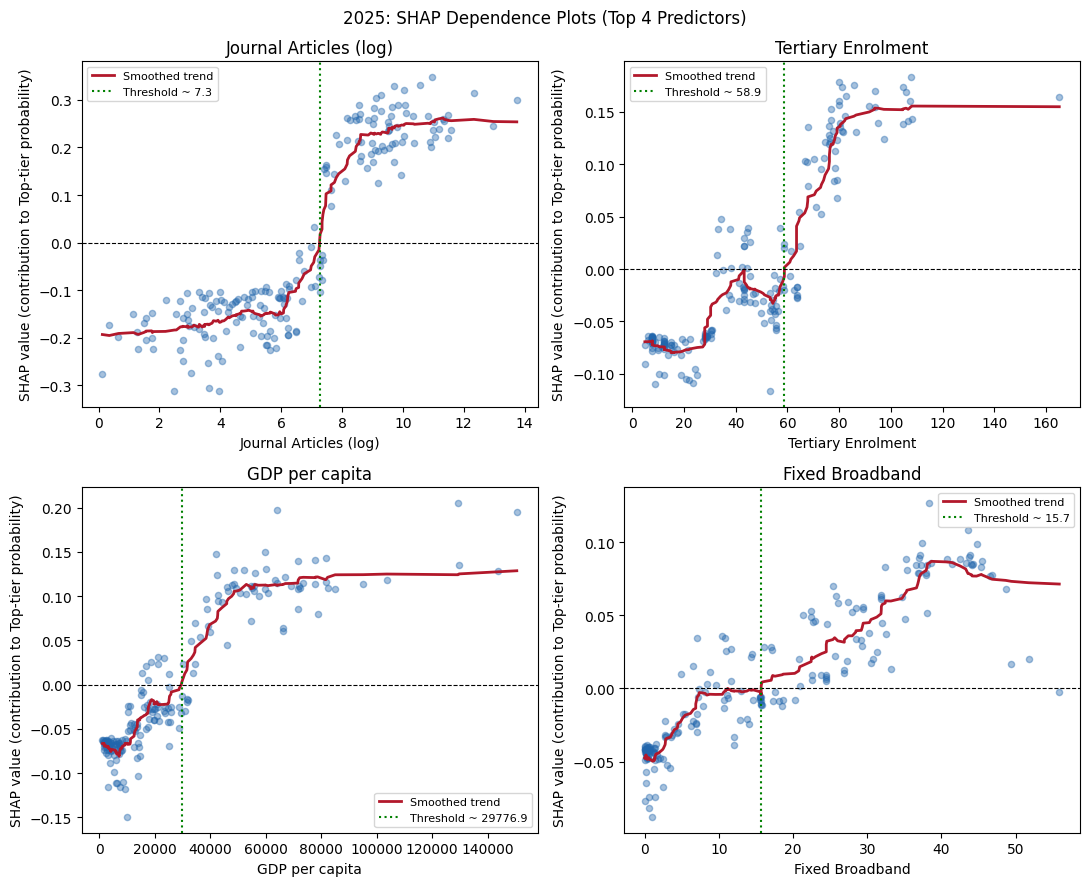

In [51]:
# ============================================================
# RQ4: SHAP dependence plots for the top 4 predictors per era
#      -- visualizes the threshold analysis directly: each panel
#      shows the feature's value on the x-axis against its SHAP
#      contribution on the y-axis, with the smoothed trend line
#      and the extracted threshold (where contribution flips
#      from negative to positive) marked explicitly.
#
# Reuses the SHAP values already computed in rq4_shap_analysis.py
# (loaded from the saved pickle) rather than refitting models.
# ============================================================

with open('rq4_shap_data.pkl', 'rb') as f:
    saved = pickle.load(f)

era_shap_data = saved['era_shap_data']
PREDICTOR_COLS = saved['PREDICTOR_COLS']
LABELS = saved['LABELS']

thresholds_df = pd.read_csv(DATA_DIR + 'processed/rq4_shap_thresholds.csv')

for era_label in ['Pre-2025', '2025']:
    X = era_shap_data[era_label]['X']
    shap_values = era_shap_data[era_label]['shap_values']

    mean_abs_shap = np.abs(shap_values).mean(axis=0)
    top4_idx = np.argsort(mean_abs_shap)[::-1][:4]

    fig, axes = plt.subplots(2, 2, figsize=(11, 9))
    axes = axes.flatten()

    for ax, idx in zip(axes, top4_idx):
        col = PREDICTOR_COLS[idx]
        label = LABELS[col]
        feature_vals = X.iloc[:, idx].values
        shap_vals_this_feature = shap_values[:, idx]

        order = np.argsort(feature_vals)
        sorted_vals = feature_vals[order]
        sorted_shap = shap_vals_this_feature[order]
        window = max(5, int(len(sorted_shap) * 0.15))
        smoothed = pd.Series(sorted_shap).rolling(window, center=True, min_periods=1).mean().values

        ax.scatter(feature_vals, shap_vals_this_feature, alpha=0.4, s=20, color='#2166ac')
        ax.plot(sorted_vals, smoothed, color='#b2182b', linewidth=2, label='Smoothed trend')
        ax.axhline(0, color='black', linewidth=0.8, linestyle='--')

        row = thresholds_df[(thresholds_df['era'] == era_label) & (thresholds_df['predictor'].str.startswith(label))]
        if len(row) and row.iloc[0]['crossing_found']:
            thresh = row.iloc[0]['threshold']
            ax.axvline(thresh, color='green', linewidth=1.5, linestyle=':', label=f'Threshold ~ {thresh:.1f}')

        ax.set_xlabel(label)
        ax.set_ylabel('SHAP value (contribution to Top-tier probability)')
        ax.set_title(label)
        ax.legend(fontsize=8)

    fig.suptitle(f'{era_label}: SHAP Dependence Plots (Top 4 Predictors)')
    fig.tight_layout()
    fname = f'plot_rq4_shap_dependence_{era_label.replace("-", "").replace(" ", "_").lower()}.png'
    fig.savefig(fname, dpi=150)
    print(f"Saved {fname}")


#Appendix for now

In [42]:
lookup = pd.read_csv(DATA_DIR + 'processed/country_region_income_lookup.csv')

MANUAL_FIXES = {
    'ETH': {'region': 'Sub-Saharan Africa', 'income_classification': 'Low income'},
    'VEN': {'region': 'Latin America & Caribbean', 'income_classification': 'Low income'},
}

for code, fixes in MANUAL_FIXES.items():
    for field, value in fixes.items():
        lookup.loc[lookup['country_code'] == code, field] = value

# Confirm the fix took
print("After fix:")
print(lookup[lookup['country_code'].isin(MANUAL_FIXES.keys())].to_string(index=False))

# Re-check how many rows still have missing region/income
still_missing = lookup[lookup['region'].isna() | lookup['income_classification'].isna()]
print(f"\nRemaining countries with missing region/income: {len(still_missing)}")
if len(still_missing):
    print(still_missing.to_string(index=False))

lookup.to_csv('country_region_income_lookup.csv', index=False)
print("\nSaved (overwritten) country_region_income_lookup.csv with manual fixes applied")

After fix:
 country_name country_code                    region income_classification  Year
     Ethiopia          ETH        Sub-Saharan Africa            Low income  1996
Venezuela, RB          VEN Latin America & Caribbean            Low income  1996

Remaining countries with missing region/income: 8
                 country_name country_code region income_classification  Year
                French Guiana          GUF    NaN                   NaN  1996
                   Martinique          MTQ    NaN                   NaN  1996
                     Anguilla          AIA    NaN                   NaN  2004
Netherlands Antilles (former)          ANT    NaN                   NaN  2004
                      Réunion          REU    NaN                   NaN  2004
                 Cook Islands          COK    NaN                   NaN  2005
                         Niue          NIU    NaN                   NaN  2009
      Jersey, Channel Islands          JEY    NaN                   NaN